In [4]:
import xarray as xr
import pandas as pd
import numpy as np

import pygmt
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle,Polygon
import proplot as plot

import cartopy.crs as ccrs
import bayspar as bsr
from tqdm import tqdm

import os

import warnings
#suppress warnings
warnings.filterwarnings('ignore')

In [5]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrien17
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrien17
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)# Matplotlib plot
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

In [6]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('nutrient-effect-on-TEX')+len('nutrient-effect-on-TEX')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'

In [7]:
# Gridded coretop
fpath = f'{local_github_path}/ncfiles/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))

fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/'
fname = 'woa23_decav91C0_t00_04.nc'
woa23_decav91C0_t00_04 = xr.open_dataset(os.path.join(fpath, fname),decode_times=False)
SST = woa23_decav91C0_t00_04['t_an'].sel(depth=0).rename('sst')
ocean_properties_ds['sst'] = SST.drop_vars('depth')
display(ocean_properties_ds)

fpath = f'{local_github_path}/ncfiles/external/'
fname = 'ds_gridded_coretop_tex_scaledRI_revised_081525.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])



coretop_df = coretop_ds_merged.to_dataframe()
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index()  # remove outliers
coretop_df

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * time           (time) float32 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,sst
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,1.502839,NaN,928.0,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,-1.64841
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.833333,NaN,1081.0,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,-1.50741
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,1.824832,NaN,332.0,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,-1.70171
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.066396,NaN,932.0,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,-1.42831
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.040640,NaN,839.0,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,-1.74881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1348,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4.516129,NaN,4018.0,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,-1.64041
1349,86.625,152.125,1878.0,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,...,21.272727,NaN,1467.0,3.324040,7.059811,9.083502,-1.156047,175.0,0.24909,-1.57041
1350,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,9.555556,NaN,3368.0,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,-1.57180
1351,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,2.870370,NaN,4443.0,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,-1.73371


In [8]:
def create_latlon_boundary(lon_min, lon_max, lat_min, lat_max, n_points=50):
    """
    Create a polygon that follows lat/lon grid lines for proper display 
    on different map projections.
    
    Parameters:
    -----------
    lon_min, lon_max : float
        Longitude bounds
    lat_min, lat_max : float  
        Latitude bounds
    n_points : int
        Number of points along each edge (more points = smoother curves)
    
    Returns:
    --------
    boundary_lons, boundary_lats : arrays
        Arrays of longitude and latitude points defining the boundary
    """
    
    # Create the four edges of the bounding box with many points
    
    # Bottom edge (lat_min, varying lon)
    bottom_lons = np.linspace(lon_min, lon_max, n_points)
    bottom_lats = np.full(n_points, lat_min)
    
    # Right edge (lon_max, varying lat)  
    right_lons = np.full(n_points, lon_max)
    right_lats = np.linspace(lat_min, lat_max, n_points)
    
    # Top edge (lat_max, varying lon) - reverse order to close polygon
    top_lons = np.linspace(lon_max, lon_min, n_points)
    top_lats = np.full(n_points, lat_max)
    
    # Left edge (lon_min, varying lat) - reverse order to close polygon
    left_lons = np.full(n_points, lon_min)  
    left_lats = np.linspace(lat_max, lat_min, n_points)
    
    # Concatenate all edges
    boundary_lons = np.concatenate([bottom_lons, right_lons, top_lons, left_lons])
    boundary_lats = np.concatenate([bottom_lats, right_lats, top_lats, left_lats])
    
    return boundary_lons, boundary_lats

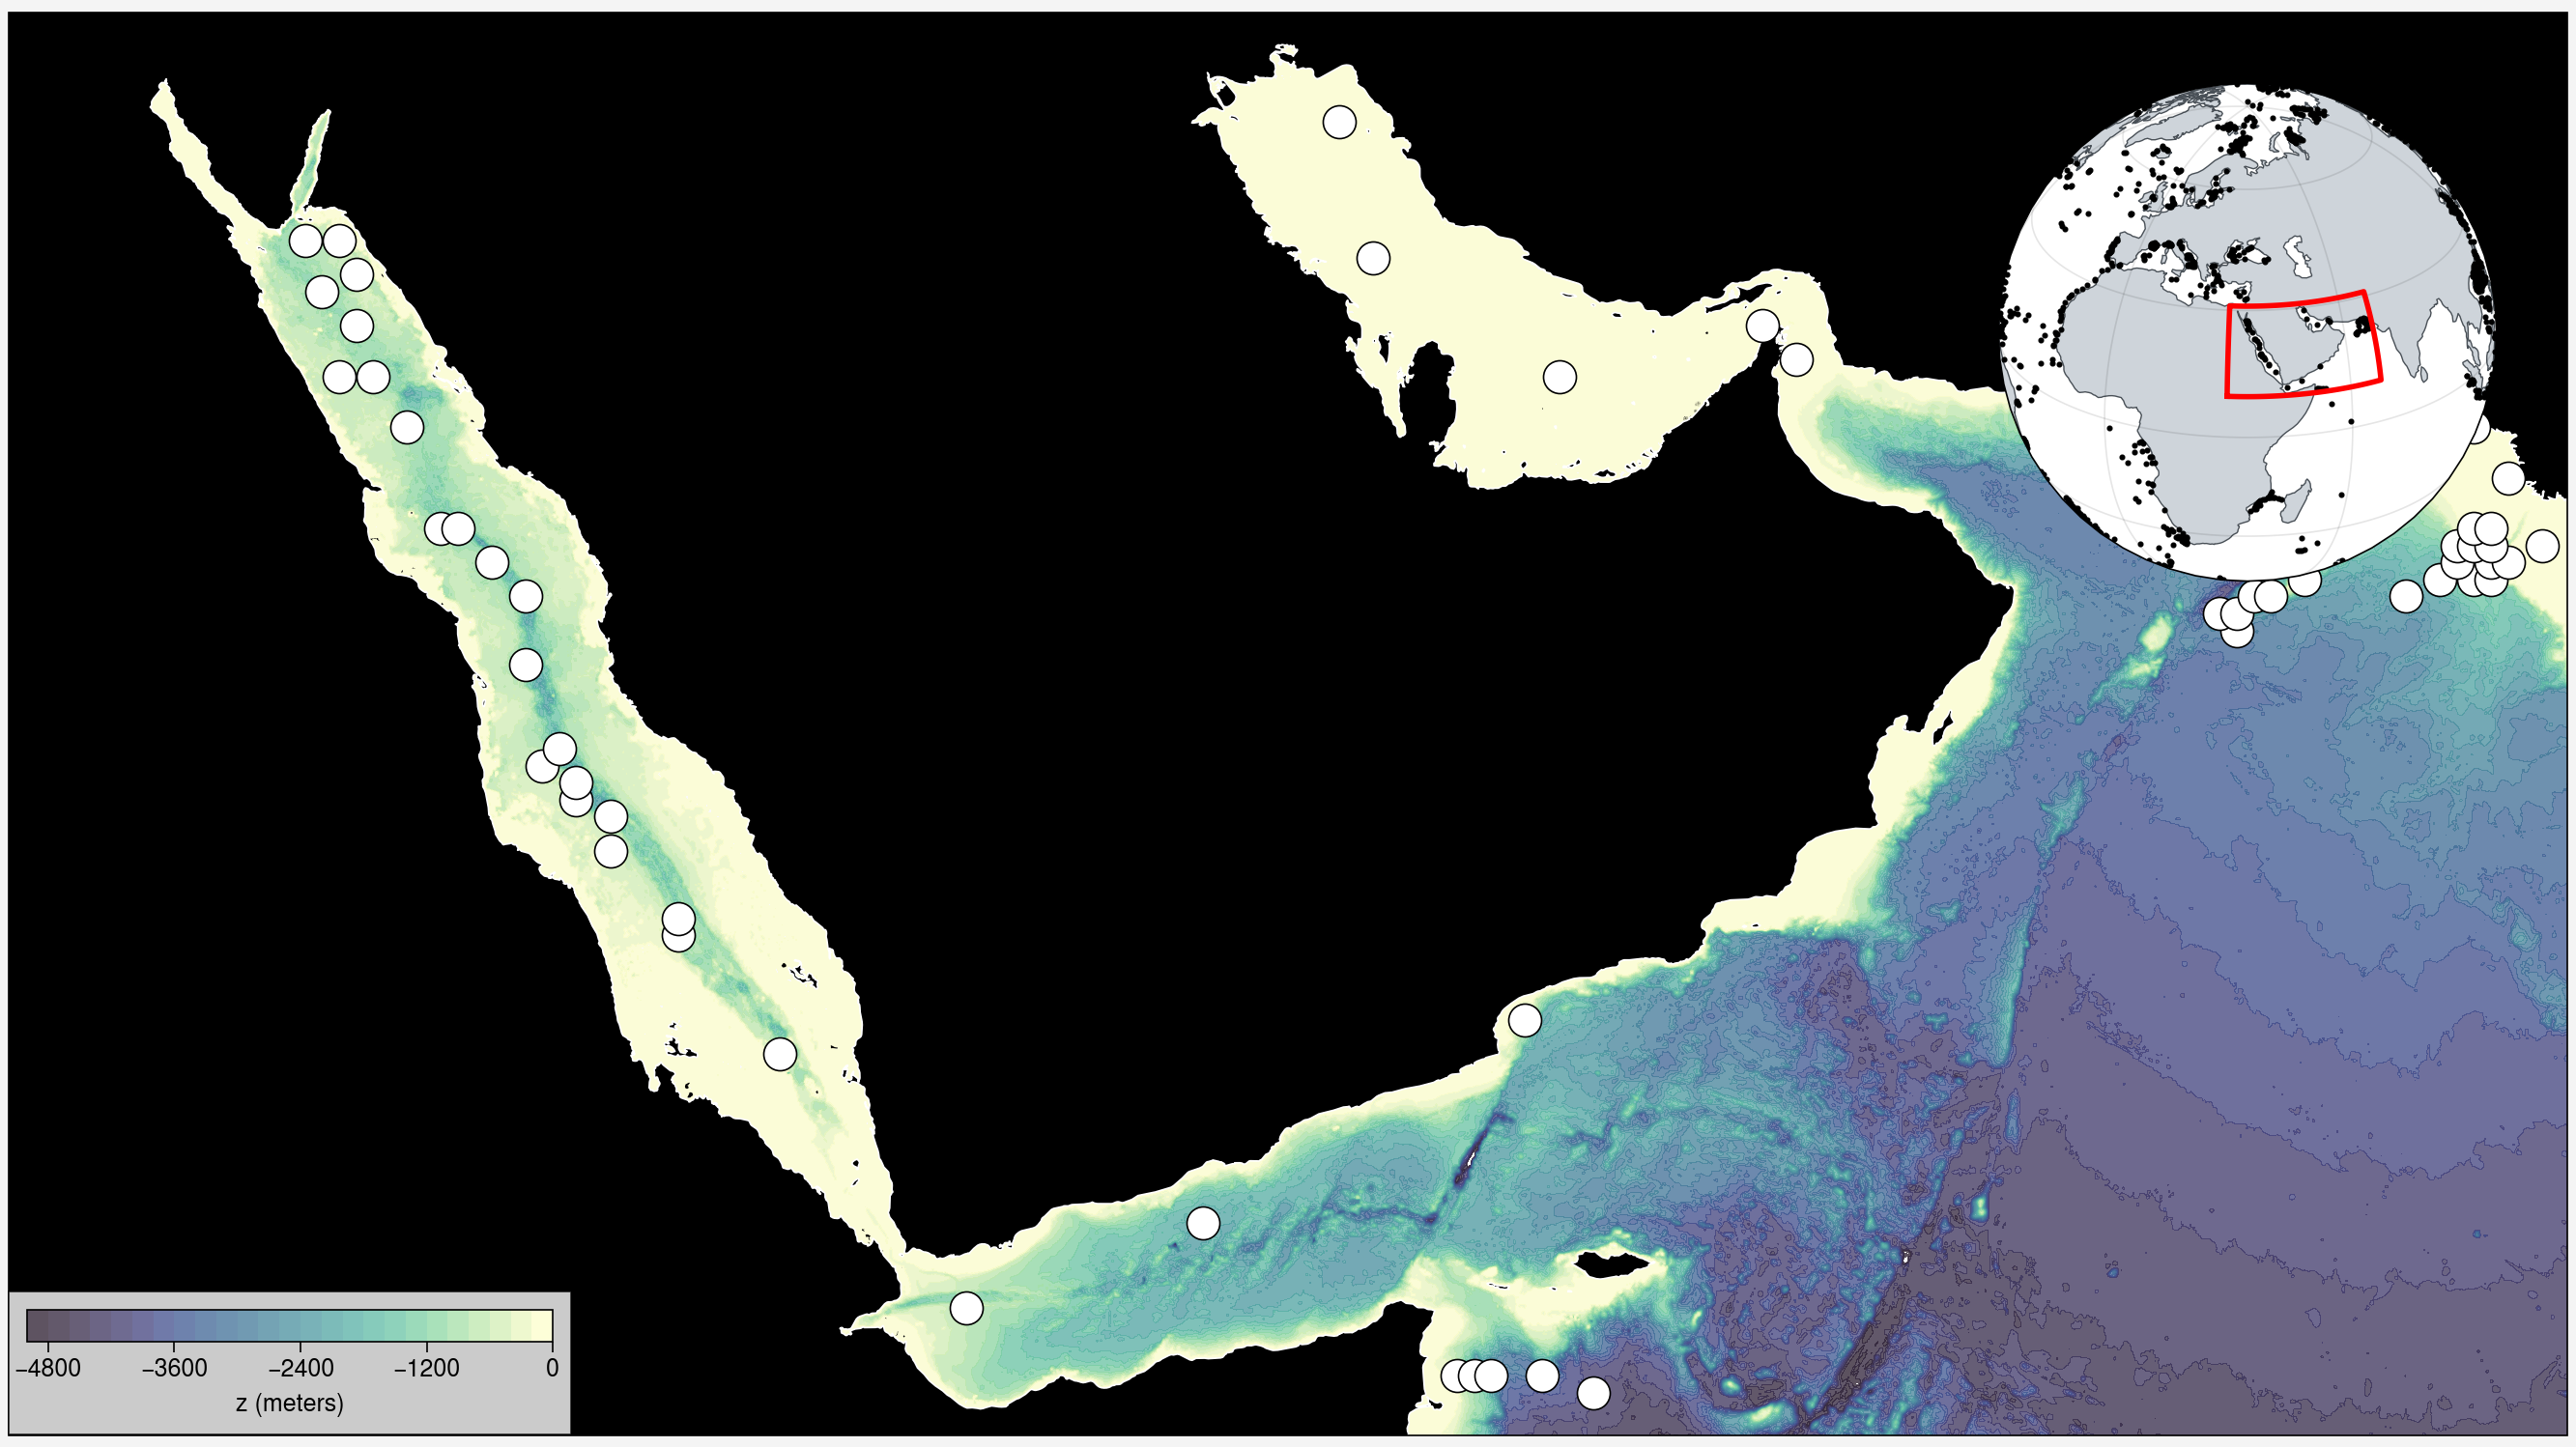

In [9]:
fig, axs = plot.subplots(proj='cyl',width=12,figsize=(13.33,7.49))
plot.rc.reso = 'hi'
lon_min, lon_max = 30.25, 68
lat_min, lat_max = 10, 31
gmt_bathy_da = pygmt.datasets.load_earth_relief(resolution="30s", region=[lon_min,lon_max,lat_min,lat_max], registration=None, data_source='igpp', use_srtm=False)

ax = axs[0,0]
ax.format(
    latlabels=False,
    lonlabels=False,
    lonlim=(lon_min,lon_max),
    latlim=(lat_min,lat_max),
    coast=True,coastzorder=2,coastcolor='w',
    land=True,landzorder=1,landcolor='k',
    alpha=0.5,
    grid=False
)

plot_data = gmt_bathy_da.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
plot_lat = gmt_bathy_da.lat
plot_lon = gmt_bathy_da.lon

m = ax.contourf(plot_lon,plot_lat,plot_data,cmap='deep_r',levels=np.arange(-5000,10,200),alpha=0.75,zorder=0)
# ax.contour(plot_lon,plot_lat,plot_data,linecolor='black',linewidth=0.25,levels=np.arange(-5000,5100,200))
ax.colorbar(m,loc='ll',shrink=20)

plot_x = coretop_df['lon']
plot_y = coretop_df['lat']

ax.scatter(plot_x,plot_y,c='w',mec='k',m='o',s=150,zorder=3)


##########################
# Create an inset axis overlapping on the top right corner of axs[0]
plot.rc.reso = 'lo'
ax_inset = axs[0].inset_axes([0.7, 0.6, 0.35, 0.35],
                             proj='ortho',proj_kw={'lon_0':35,'lat_0':25})
ax_inset.format(land=True, 
                landcolor='gray4',landzorder=0,
                grid=True,
                coast=True, coastcolor='gray7',coastlinewidth=0.5,coastzorder=1,
                )


# Your modified code section:
# Replace this part:
# rect = Rectangle((lon_min,lat_min), lon_max - lon_min, lat_max - lat_min, edgecolor='red9',
#                  facecolor='none',transform=ccrs.PlateCarree())
# ax_inset.add_patch(rect)

# With this:
boundary_lons, boundary_lats = create_latlon_boundary(lon_min, lon_max, lat_min, lat_max, n_points=50)

# Method 1: Using plot (recommended - simple and effective)
ax_inset.plot(boundary_lons, boundary_lats, 'red', linewidth=2, 
              transform=ccrs.PlateCarree(), zorder=10)
ax_inset.scatter(coretop_df['lon'],coretop_df['lat'],m='.',c='k',s=10,zorder=2)




fpath = f'{local_github_path}/figures/viz_for_presentations/IMOG2025'
fname = 'map01_bathymetry_coretop'
fig.savefig(
    os.path.join(fpath,fname+'.png'),
    box_inches='tight',embed_fonts=True,dpi=600
)

In [10]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
fname = 'woa23_decav91C0_t00_04.nc'

T_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
woa23_temp = T_da.t_an.squeeze('time')
woa23_temp

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
[105753600 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
    time     float32 1.878e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [11]:
from pathlib import Path
import numpy as np
import xarray as xr
import re

# --- inputs ---
fpath = f'{local_github_path}/ncfiles/external/WOA01'
fname = 't00an1'
txt = os.path.join(fpath,fname)   # your decompressed file
var = "temperature"   # t = temperature
fill = -99.9999

# 1° grid (an1) constants
nlon, nlat, nlev = 360, 180, 33
lon = np.arange(0.5, 360.0, 1.0)
lat = np.arange(-89.5, 90.0, 1.0)
depth = np.array([0,10,20,30,50,75,100,125,150,200,250,300,
                  400,500,600,700,800,900,1000,1100,1200,1300,1400,1500,
                  1750,2000,2500,3000,3500,4000,4500,5000,5500], float)

nlon, nlat, nlev = 360, 180, 33
nvals_per_level = nlon * nlat
expected_total  = nvals_per_level * nlev

# Regex that finds floats even when back-to-back, e.g. ...-99.9999-99.9999...
pat = re.compile(r'[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?')

# --- read all numbers from ASCII (10 per line, Fortran f8.4 style) ---
vals = []
with open(txt, 'r') as f:
    for line in f:
        vals.extend(pat.findall(line))

vals = np.array(vals, dtype=float)
expected = nlon * nlat * nlev
if vals.size != expected:
    raise ValueError(f"Got {vals.size} values, expected {expected} "
                     "(is this the 1° annual analyzed file?)")

# File order is (level, lat, lon) with lon running fastest
vals = vals.reshape((nlev, nlat, nlon))
vals = np.where(np.isclose(vals, fill), np.nan, vals)

woa01_temp_ds = xr.Dataset(
    {var: (("depth","lat","lon"), vals)},
    coords={"depth": depth, "lat": lat, "lon": lon},
    attrs={"source":"WOA01 annual analyzed (ASCII) converted to NetCDF",
           "note":"lon-fastest, start at 0.5E x 89.5S"}
)
woa01_temp_ds[var].attrs.update(units="degC")
woa01_temp_ds.to_netcdf(os.path.join(fpath,"t00an1.nc"))
print(woa01_temp_ds)

<xarray.Dataset>
Dimensions:      (depth: 33, lat: 180, lon: 360)
Coordinates:
  * depth        (depth) float64 0.0 10.0 20.0 30.0 ... 4.5e+03 5e+03 5.5e+03
  * lat          (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon          (lon) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    temperature  (depth, lat, lon) float64 nan nan nan nan ... nan nan nan nan
Attributes:
    source:   WOA01 annual analyzed (ASCII) converted to NetCDF
    note:     lon-fastest, start at 0.5E x 89.5S


In [12]:
from pathlib import Path
import numpy as np
import xarray as xr
import re

# --- inputs ---
fpath = f'{local_github_path}/ncfiles/external/WOA01'
fname = 'n00an1'
txt = os.path.join(fpath,fname)   # your decompressed file
var = "nitrate"   # t = temperature
fill = -99.9999

# 1° grid (an1) constants
nlon, nlat, nlev = 360, 180, 33
lon = np.arange(0.5, 360.0, 1.0)
lat = np.arange(-89.5, 90.0, 1.0)
depth = np.array([0,10,20,30,50,75,100,125,150,200,250,300,
                  400,500,600,700,800,900,1000,1100,1200,1300,1400,1500,
                  1750,2000,2500,3000,3500,4000,4500,5000,5500], float)

nlon, nlat, nlev = 360, 180, 33
nvals_per_level = nlon * nlat
expected_total  = nvals_per_level * nlev

# Regex that finds floats even when back-to-back, e.g. ...-99.9999-99.9999...
pat = re.compile(r'[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?')

# --- read all numbers from ASCII (10 per line, Fortran f8.4 style) ---
vals = []
with open(txt, 'r') as f:
    for line in f:
        vals.extend(pat.findall(line))

vals = np.array(vals, dtype=float)
expected = nlon * nlat * nlev
if vals.size != expected:
    raise ValueError(f"Got {vals.size} values, expected {expected} "
                     "(is this the 1° annual analyzed file?)")

# File order is (level, lat, lon) with lon running fastest
vals = vals.reshape((nlev, nlat, nlon))
vals = np.where(np.isclose(vals, fill), np.nan, vals)

woa01_nitrate_ds = xr.Dataset(
    {var: (("depth","lat","lon"), vals)},
    coords={"depth": depth, "lat": lat, "lon": lon},
    attrs={"source":"WOA01 annual analyzed (ASCII) converted to NetCDF",
           "note":"lon-fastest, start at 0.5E x 89.5S"}
)
woa01_nitrate_ds[var].attrs.update(units="degC")
woa01_nitrate_ds.to_netcdf(os.path.join(fpath,"n00an1.nc"))
print(woa01_nitrate_ds)

<xarray.Dataset>
Dimensions:  (depth: 33, lat: 180, lon: 360)
Coordinates:
  * depth    (depth) float64 0.0 10.0 20.0 30.0 ... 4e+03 4.5e+03 5e+03 5.5e+03
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
Data variables:
    nitrate  (depth, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
Attributes:
    source:   WOA01 annual analyzed (ASCII) converted to NetCDF
    note:     lon-fastest, start at 0.5E x 89.5S


In [13]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/nitrate'
fname = 'woa23_all_n00_01.nc'

no3_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
woa23_no3 = no3_da.n_an.squeeze('time')
woa23_no3

<xarray.DataArray 'n_an' (depth: 102, lat: 180, lon: 360)>
[6609600 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
    time     float32 3.894e+03
Attributes:
    standard_name:  moles_of_nitrate_per_unit_mass_in_sea_water
    long_name:      Objectively analyzed mean fields for moles_of_nitrate_per...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          micromoles_per_kilogram

In [14]:
fpath = f'{local_github_path}/ncfiles/external/CMEMS'
fname = 'CMEMS_no3_ANN_199301_202212_climo.nc'

cmems_no3_ds = xr.open_dataset(os.path.join(fpath, fname)).no3.squeeze('time')
cmems_no3_ds = cmems_no3_ds.rename({'latitude':'lat','longitude':'lon'})
cmems_no3_ds

<xarray.DataArray 'no3' (depth: 75, lat: 681, lon: 1440)>
[73548000 values with dtype=float32]
Coordinates:
  * lon      (lon) float32 -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float32 -80.0 -79.75 -79.5 -79.25 ... 89.25 89.5 89.75 90.0
  * depth    (depth) float32 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
    time     datetime64[ns] 2007-12-31T16:18:45
Attributes:
    long_name:      Nitrate
    standard_name:  mole_concentration_of_nitrate_in_sea_water
    units:          mmol m-3
    unit_long:      millimoles of Nitrate per cubic meter
    valid_min:      0.0
    valid_max:      59.31268
    cell_methods:   time: mean

In [15]:
def oblique_section_lonlat(lon1, lat1, lon2, lat2, n_points=100):
    """
    Create a series of points defining an oblique section between two lat/lon points.
    
    Parameters:
    -----------
    lon1, lat1 : float
        Longitude and latitude of the starting point
    lon2, lat2 : float  
        Longitude and latitude of the ending point
    n_points : int
        Number of points along the section (more points = smoother line)
    
    Returns:
    --------
    section_lons, section_lats : arrays
        Arrays of longitude and latitude points defining the oblique section
    """
    
    section_lons = np.linspace(lon1, lon2, n_points)
    section_lats = np.linspace(lat1, lat2, n_points)
    
    return section_lons, section_lats

In [16]:
ocean_properties_ds


<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * time           (time) float32 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [17]:
coretop_df.columns

Index(['lat', 'lon', 'time', 'region_ID', 'tex_count', 'tex_median',
       'tex_mean', 'tex_std', 'scaledRI_count', 'scaledRI_median',
       'scaledRI_mean', 'scaledRI_std', 'gdgt23ratio_count',
       'gdgt23ratio_median', 'gdgt23ratio_mean', 'gdgt23ratio_std',
       'modernWaterDepth_mean', 'mahalanobis_distance_mean', 'no3_sf2tc_avg',
       'no3_tc', 't_sf2tc_avg', 'tc_depth', 't_tc', 'sst'],
      dtype='object')

In [18]:
coretop_df['predTEX_thisstudy'] = 0.012 * coretop_df['t_sf2tc_avg'] + 0.330
coretop_df['TEXres_thisstudy'] = coretop_df['tex_median'] - coretop_df['predTEX_thisstudy']

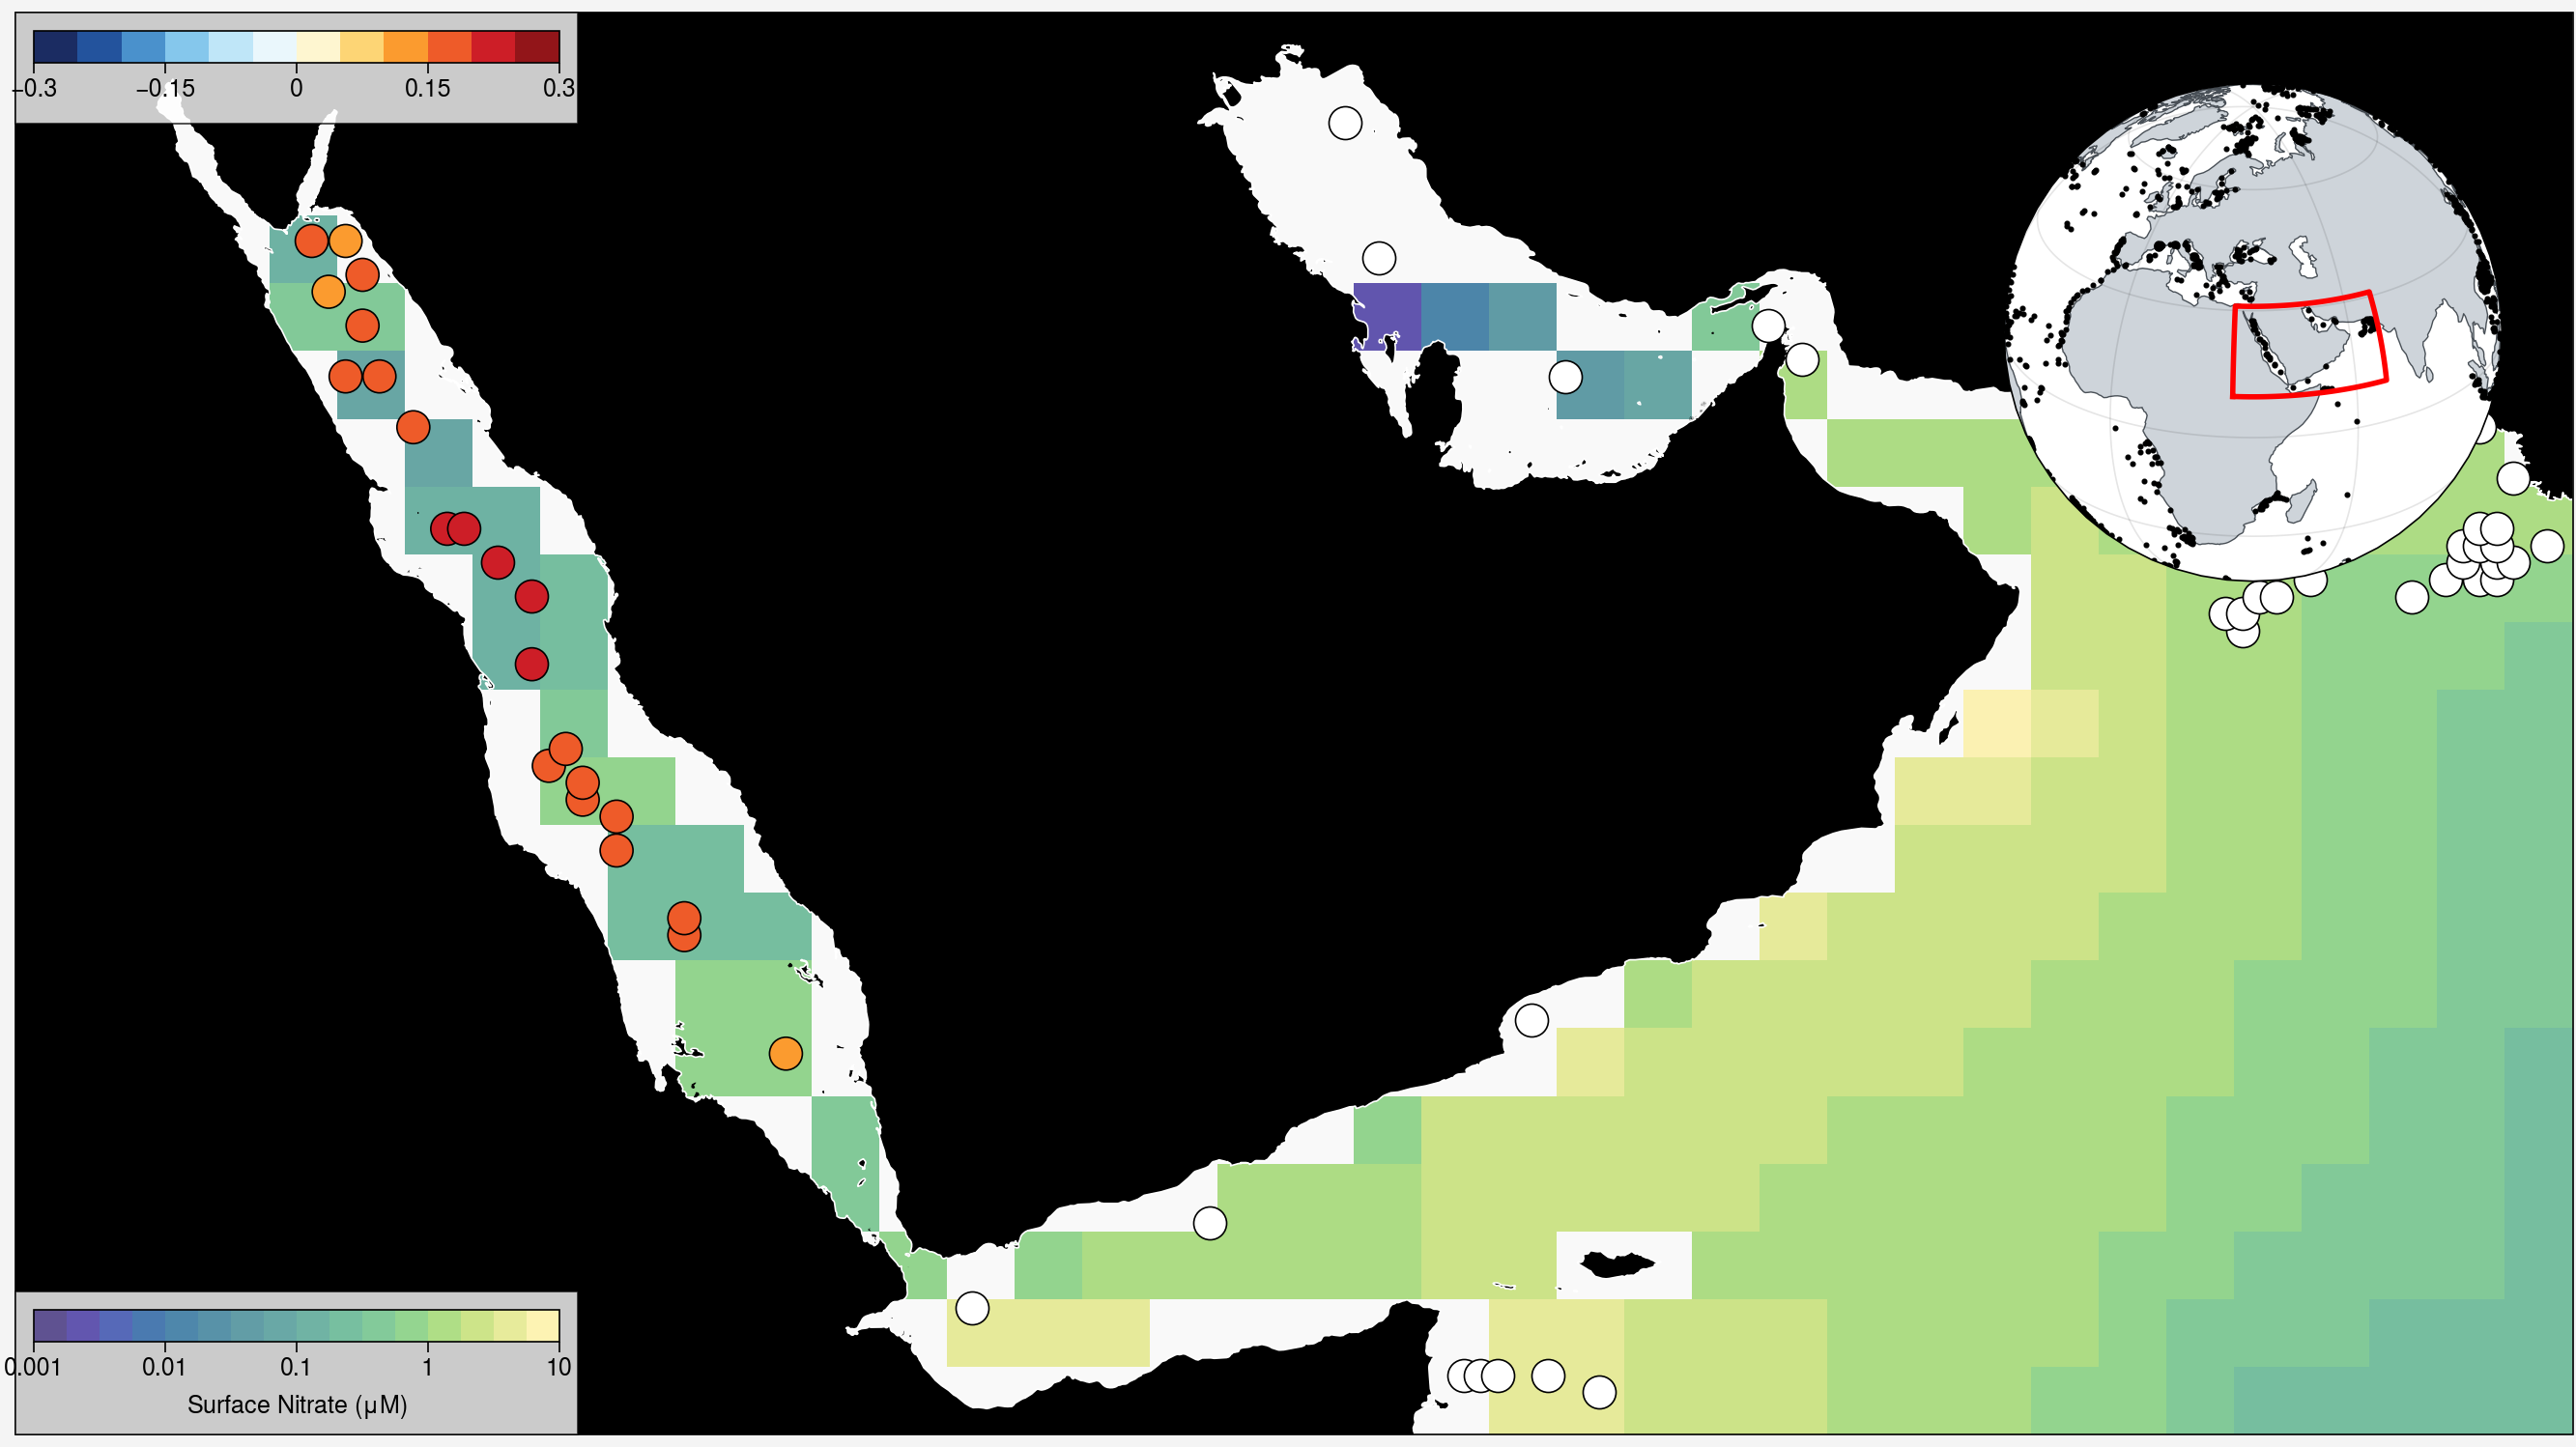

In [19]:

def plot_reasea_map(dataset_,depth=0):

    fig, axs = plot.subplots(proj='cyl',width=12,figsize=(13.33,7.49))
    plot.rc.reso = 'hi'
    lon_min, lon_max = 30.25, 68
    lat_min, lat_max = 10, 31
    gmt_bathy_da = pygmt.datasets.load_earth_relief(resolution="30s", region=[lon_min,lon_max,lat_min,lat_max], registration=None, data_source='igpp', use_srtm=False)

    ax = axs[0,0]
    ax.format(
        latlabels=False,
        lonlabels=False,
        lonlim=(lon_min,lon_max),
        latlim=(lat_min,lat_max),
        coast=True,coastzorder=2,coastcolor='w',
        land=True,landzorder=1,landcolor='k',
        alpha=0.5,
        grid=False
    )

    if dataset_=='woa23_temp':
        plot_data = woa23_temp.sel(depth=depth,method='nearest')
        plot_lat = woa23_temp.lat
        plot_lon = woa23_temp.lon
        cmap='thermal'
        levels=np.arange(20,30.5,0.5) # if depth == 0 else np.arange(10,25.5,0.5)
        cbar_shrink=20
        bar_title_str = r'SST ($\degree$C)'
    elif dataset_=='woa01_temp':
        plot_data = woa01_temp_ds.temperature.sel(depth=depth,method='nearest')
        plot_lat = woa01_temp_ds.lat
        plot_lon = woa01_temp_ds.lon
        cmap='thermal'
        levels=np.arange(20,30.5,0.5) # if depth == 0 else np.arange(10,25.5,0.5)
        cbar_shrink=20
        bar_title_str = r'SST ($\degree$C)'
    elif dataset_=='woa23_no3':
        plot_data = np.log10(woa23_no3.sel(depth=depth,method='nearest'))
        plot_lat = woa23_no3.lat
        plot_lon = woa23_no3.lon
        cmap='haline'
        levels=np.arange(-3,1.1,0.25)
        cbar_tick_labels=['0.001','0.01','0.1','1','10','10']
        cbar_shrink=20
        bar_title_str = r'Surface Nitrate ($\mu$M)'
    elif dataset_=='woa01_no3':
        plot_data = np.log10(woa01_nitrate_ds.nitrate.sel(depth=depth,method='nearest'))
        plot_lat = woa01_nitrate_ds.nitrate.lat
        plot_lon = woa01_nitrate_ds.nitrate.lon
        cmap='haline'
        levels=np.arange(-3,1.1,0.25)
        bar_title_str = r'Surface Nitrate ($\mu$M)'
        cbar_tick_labels=['0.001','0.01','0.1','1','10','10']
        cbar_shrink=20
    elif dataset_=='cmems_no3':
        plot_data = np.log10(cmems_no3_ds.sel(depth=depth,method='nearest'))
        plot_lat = cmems_no3_ds.lat
        plot_lon = cmems_no3_ds.lon
        cmap='haline'
        levels=np.arange(-3,1.1,0.25)
        cbar_tick_labels=['0.001','0.01','0.1','1','10','10']
        cbar_shrink=20
        bar_title_str = r'Surface Nitrate ($\mu$M)'
    elif dataset_=='cmems_no3_sf2tc':
        plot_data = np.log10(ocean_properties_ds.squeeze('time')['no3_sf2tc_avg'])
        plot_lat = ocean_properties_ds.squeeze('time').lat
        plot_lon = ocean_properties_ds.squeeze('time').lon
        cmap='haline'
        levels=np.arange(-3,1.1,0.25)
        cbar_tick_labels=['0.001','0.01','0.1','1','10','10']
        cbar_shrink=20
        bar_title_str = r'Surface Nitrate ($\mu$M)'
    else:
        raise ValueError("dataset_ must be one of 'woa23_temp', 'woa01_temp', 'woa23_no3', or 'woa01_no3'")


    m = ax.pcolormesh(plot_lon,plot_lat,plot_data,
                      cmap=cmap,
                      levels=levels,alpha=0.75,zorder=0)

    ax.colorbar(m,loc='ll',shrink=cbar_shrink,title=bar_title_str,
                ticklabels=cbar_tick_labels if 'cbar_tick_labels' in locals() else None,)

    #####
    # plot_x = coretop_df['lon']
    # plot_y = coretop_df['lat']
    # ax.scatter(plot_x,plot_y,c='w',mec='k',m='o',s=150,zorder=3)

    grouped = coretop_df.groupby('region_ID')
    for name, group in grouped:
        plot_x = group['lon']
        plot_y = group['lat']
        m = ax.scatter(plot_x,plot_y,
                c=group['TEXres_thisstudy'] if name==31 else 'w',
                cmap = 'coldhot' if name==31 else None,
                levels = np.arange(-0.3,0.31,0.05) if name==31 else None,
                # facecolor='w' if name==31 else 'none',
                # c='w',
                mec='k',
                # mew=2,
                m='o',s=150,zorder=3)

        if name==31:
            ax.colorbar(m,loc='ul',shrink=20)

    ##########################
    # Create an inset axis overlapping on the top right corner of axs[0]
    plot.rc.reso = 'lo'
    ax_inset = axs[0].inset_axes([0.7, 0.6, 0.35, 0.35],
                                proj='ortho',proj_kw={'lon_0':35,'lat_0':25})
    ax_inset.format(land=True, 
                    landcolor='gray4',landzorder=0,
                    grid=True,
                    coast=True, coastcolor='gray7',coastlinewidth=0.5,coastzorder=1,
                    )


    # Your modified code section:
    # Replace this part:
    # rect = Rectangle((lon_min,lat_min), lon_max - lon_min, lat_max - lat_min, edgecolor='red9',
    #                  facecolor='none',transform=ccrs.PlateCarree())
    # ax_inset.add_patch(rect)

    # With this:
    boundary_lons, boundary_lats = create_latlon_boundary(lon_min, lon_max, lat_min, lat_max, n_points=50)

    # Method 1: Using plot (recommended - simple and effective)
    ax_inset.plot(boundary_lons, boundary_lats, 'red', linewidth=2, 
                transform=ccrs.PlateCarree(), zorder=10)
    ax_inset.scatter(coretop_df['lon'],coretop_df['lat'],m='.',c='k',s=10,zorder=2)




    fpath = f'{local_github_path}/figures/viz_for_presentations/IMOG2025'
    fname = f'map01_{dataset_}_{depth}m_coretop_reasea_base'
    fig.savefig(
        os.path.join(fpath,fname+'.png'),
        box_inches='tight',embed_fonts=True,dpi=600
    )

    return fig, axs

fig, axs = plot_reasea_map('woa01_no3',depth=0)

In [20]:
coretop_df['no3_100m'] = np.nan
coretop_df['no3_0m'] = np.nan
for i in tqdm(range(len(coretop_df))):
    match_lat = coretop_df['lat'].iloc[i]
    match_lon = coretop_df['lon'].iloc[i]
    
    coretop_df.loc[i, 'no3_0m'] = np.atleast_1d(woa01_nitrate_ds['nitrate'].sel(lat=match_lat,
                                                                                  lon=match_lon,
                                                                                  depth=0,method='nearest').values)[0]
    
    coretop_df.loc[i, 'no3_100m'] = np.atleast_1d(woa01_nitrate_ds['nitrate'].sel(lat=match_lat,
                                                                                  lon=match_lon,
                                                                                  depth=100,method='nearest').values)[0]

  0%|          | 0/1353 [00:00<?, ?it/s]

100%|██████████| 1353/1353 [00:03<00:00, 342.51it/s]


-0.36274674850853333 0.11597628750977727


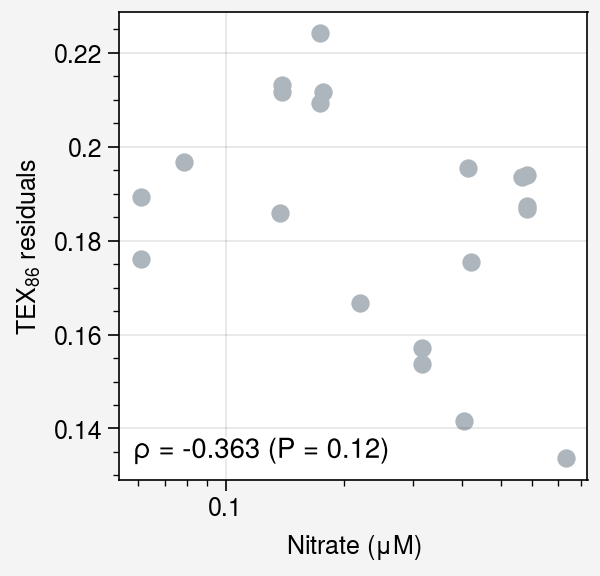

In [22]:
fig, axs  = plot.subplots(width=3)

plot_data = coretop_df[coretop_df.region_ID==31]
plot_x = plot_data['no3_0m']
plot_y = plot_data['TEXres_thisstudy']

ax = axs[0]
ax.scatter(plot_x,plot_y,c='gray5')

## spearman rho and p value
from scipy.stats import spearmanr

nonnan_idx = ~plot_x.isnull() & ~plot_y.isnull()
rho, pval = spearmanr(plot_x[nonnan_idx],plot_y[nonnan_idx])
print(rho, pval)

ax.format(
    xlabel=r'Nitrate ($\mu$M)',
    ylabel=r'TEX$_{86}$ residuals',
    xscale='log',
    lltitle=r'$\rho$ = '+f'{rho:.3f}'+r' ($P$ = '+f'{pval:.2f})'
)


fpath = f'{local_github_path}/figures/viz_for_presentations/IMOG2025'
fname = f'redsea_scatter_nitrate_texres_0m'
fig.savefig(
    os.path.join(fpath,fname+'.png'),
    box_inches='tight',embed_fonts=True,dpi=600
)


In [23]:
cmems_no3_ds

<xarray.DataArray 'no3' (depth: 75, lat: 681, lon: 1440)>
[73548000 values with dtype=float32]
Coordinates:
  * lon      (lon) float32 -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float32 -80.0 -79.75 -79.5 -79.25 ... 89.25 89.5 89.75 90.0
  * depth    (depth) float32 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
    time     datetime64[ns] 2007-12-31T16:18:45
Attributes:
    long_name:      Nitrate
    standard_name:  mole_concentration_of_nitrate_in_sea_water
    units:          mmol m-3
    unit_long:      millimoles of Nitrate per cubic meter
    valid_min:      0.0
    valid_max:      59.31268
    cell_methods:   time: mean

(Figure(nrows=1, ncols=1, figwidth=10.0, figheight=4.0),
 SubplotGrid(nrows=1, ncols=1, length=1))

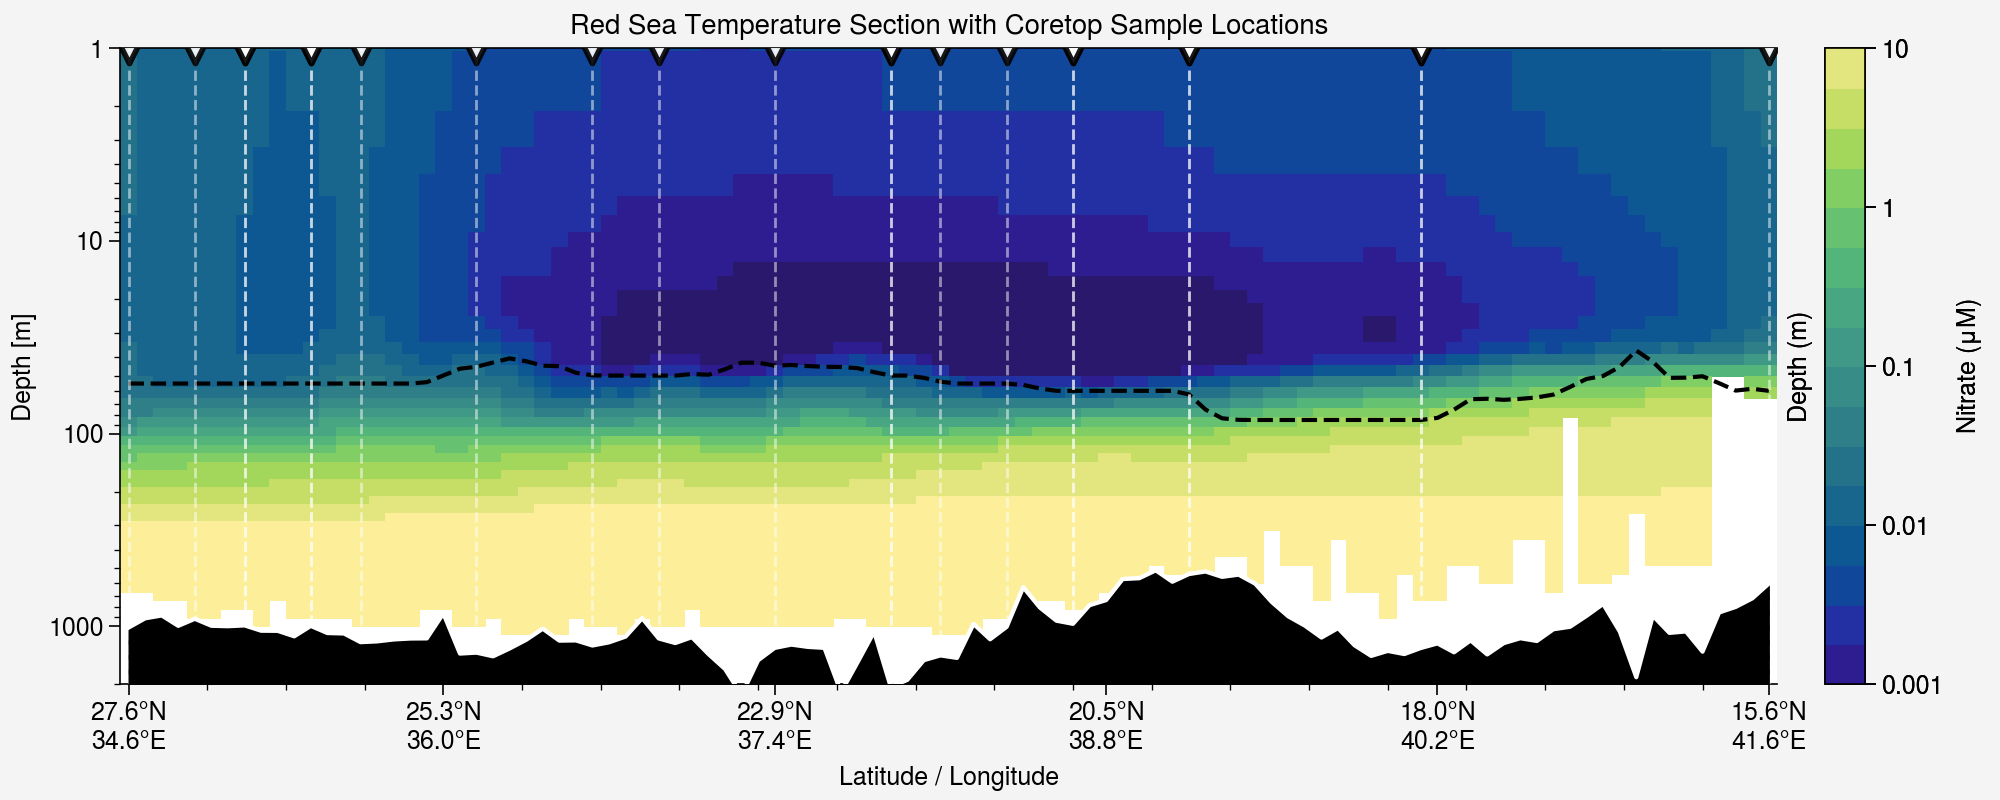

In [49]:
def plot_redsea_section(dataset_,yscale='linear'):
    redsea_coretop_df = coretop_df[coretop_df['region_ID']==31].copy().reset_index(drop=True)
    lon_min, lon_max = redsea_coretop_df['lon'].min(), redsea_coretop_df['lon'].max()
    lat_min, lat_max = redsea_coretop_df['lat'].min(), redsea_coretop_df['lat'].max()

    section_lons, section_lats = oblique_section_lonlat(lon_min, lat_max, lon_max, lat_min, n_points=100)

    if dataset_=='woa23_temp':
        data_da = woa23_temp
    elif dataset_=='woa01_temp':
        data_da = woa01_temp_ds.temperature
    elif dataset_ == 'cmems_no3':
        data_da = np.log10(cmems_no3_ds)
    else:
        raise ValueError("dataset_ must be one of 'woa23_temp' or 'woa01_temp'")

    redsea_section = data_da.interp(lon=xr.DataArray(section_lons, dims="points"),
                                        lat=xr.DataArray(section_lats, dims="points"),
                                        method="linear")
    redsea_tc_depth_sections = ocean_properties_ds.tc_depth.interp(
        lon=xr.DataArray(section_lons, dims="points"),
        lat=xr.DataArray(section_lats, dims="points"),
        method="linear"
    )

    # Match coretop points to section coordinates (following your example approach)
    redsea_coretop_df['match_section_lat'] = np.nan
    redsea_coretop_df['match_section_lon'] = np.nan
    redsea_coretop_df['match_point_index'] = np.nan
    for i in range(len(redsea_coretop_df)):
        # Find the closest point on the section to this coretop sample
        match_point = np.nanargmin(abs(redsea_section.lon - redsea_coretop_df.iloc[i]['lon']))
        # Extract the coordinates of that matched point
        redsea_coretop_df.loc[i, 'match_section_lat'] = np.atleast_1d(redsea_section.isel(points=match_point).lat)[0]
        redsea_coretop_df.loc[i, 'match_section_lon'] = np.atleast_1d(redsea_section.isel(points=match_point).lon)[0]
        redsea_coretop_df.loc[i, 'match_point_index'] = match_point


    fig, axs = plot.subplots(figsize=(10,4))

    ax = axs[0]
    if 'temp' in dataset_:
        levels = np.arange(20, 30.5, 0.5)
        cmap = 'thermal'
        label = r'Temperature ($\degree$C)'
        cbar_kwargs = {'label': label, 'ticks': np.arange(20, 30.5, 0.5)}
    else:
        levels = np.arange(-3, 1.1, 0.25)
        cmap = 'haline'
        label = r'Nitrate ($\mu$M)'
        # Specify both tick positions and labels
        tick_positions = [-3, -2, -1, 0, 1]  # positions on your data scale
        tick_labels = ['0.001', '0.01', '0.1', '1', '10']  # corresponding labels
        cbar_kwargs = {'label': label, 'ticks': tick_positions}

    redsea_section.plot(
        ax=ax,
        yincrease=False,
        cmap=cmap,
        levels=levels,
        cbar_kwargs=cbar_kwargs
    )

    # If using option 2, set custom tick labels after plotting
    if 'temp' not in dataset_:
        cbar = ax.collections[0].colorbar
        cbar.set_ticklabels(tick_labels)
        
    ax.plot(redsea_tc_depth_sections.points, redsea_tc_depth_sections, 'k--', label='Thermocline Depth')

    ## plot bathymetry
    bathy = gmt_bathy_da.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
    bathy_section = bathy.interp(lon=xr.DataArray(section_lons, dims="points"),
                                lat=xr.DataArray(section_lats, dims="points"),
                                method="linear") * -1
    ax2 = ax.twinx()
    ax2.fill_between(bathy_section.points, bathy_section, 2000, color='k', zorder=0)
    ax2.plot(bathy_section.points, bathy_section, 'w-')
    ax2.set_ylim(-5000,0)
    ax2.set_ylabel('Depth (m)')
    ax2.invert_yaxis()
    ax2.spines['left'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.yaxis.set_ticks_position('none')
    ax2.grid(False)

    # Plot coretop points using the matched section coordinates
    ax.scatter(redsea_coretop_df['match_point_index'], 
            np.full(len(redsea_coretop_df), 1),
            m='v',
            c='white', edgecolor='black', s=120, linewidth=2, zorder=15, 
            label='Coretop Samples', alpha=0.9)

    ### plot vlines of coretop points
    for idx in redsea_coretop_df['match_point_index']:
        ax.axvline(x=idx, color='w', linestyle='--', linewidth=1, alpha=0.5, zorder=5)


    # # Also plot on bathymetry axis for reference
    # ax2.scatter(redsea_coretop_df['match_point_index'], 
    #            -abs(redsea_coretop_df['modernWaterDepth_mean']), 
    #            c='red', edgecolor='black', s=100, linewidth=1.5, zorder=10, alpha=0.8)

    ax.format(
        ylim=(2000,1),
        yscale=yscale,
    )
    ax2.format(
        ylim=(2000,1),
        yscale=yscale,        
    )

    # Create custom x-axis labels with lat/lon
    n_ticks = 6  # Number of tick marks
    tick_indices = np.linspace(0, len(section_lons)-1, n_ticks).astype(int)
    tick_positions = tick_indices
    tick_labels = []

    for i in tick_indices:
        lat = section_lats[i]
        lon = section_lons[i]
        # Format the labels to show both lat and lon
        label = f'{lat:.1f}°N\n{lon:.1f}°E'
        tick_labels.append(label)

    # Set custom ticks and labels
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_xlabel('Latitude / Longitude')

    # Add legend
    # ax.legend(loc='upper right')

    # Set title
    ax.set_title('Red Sea Temperature Section with Coretop Sample Locations')

    fpath = f'{local_github_path}/figures/viz_for_presentations/IMOG2025'
    fname = f'map02_{dataset_}_redsea_section'
    fig.savefig(
        os.path.join(fpath,fname+'.png'),
        box_inches='tight',embed_fonts=True,dpi=600
    )
    
    return fig, axs

plot_redsea_section('cmems_no3',yscale='log')

In [17]:
coretop_df.columns

Index(['lat', 'lon', 'time', 'region_ID', 'tex_count', 'tex_median',
       'tex_mean', 'tex_std', 'scaledRI_count', 'scaledRI_median',
       'scaledRI_mean', 'scaledRI_std', 'gdgt23ratio_count',
       'gdgt23ratio_median', 'gdgt23ratio_mean', 'gdgt23ratio_std',
       'modernWaterDepth_mean', 'mahalanobis_distance_mean', 'no3_sf2tc_avg',
       'no3_tc', 't_sf2tc_avg', 'tc_depth', 't_tc', 'sst'],
      dtype='object')

In [37]:
coretop_df['predTEX_BAYSPAR-sst'] = np.nan
coretop_df['predT_BAYSPAR-sst'] = np.nan
for i in tqdm(range(len(coretop_df))):
    coretop_df['predTEX_BAYSPAR-sst'].iloc[i] = bsr.predict_tex(np.atleast_1d(coretop_df['sst'].iloc[i]),
                                                           lon=coretop_df['lon'].iloc[i],
                                                           lat=coretop_df['lat'].iloc[i],
                                                           temptype='sst').percentile(50)[0]

    coretop_df['predT_BAYSPAR-sst'].iloc[i] = bsr.predict_seatemp(np.atleast_1d(coretop_df['tex_median'].iloc[i]),
                                                           lon=coretop_df['lon'].iloc[i],
                                                           lat=coretop_df['lat'].iloc[i],
                                                           prior_std=6,
                                                           temptype='sst').percentile(50)[0]
    
coretop_df['TEXres_BAYSPAR-sst'] = coretop_df['tex_median'] - coretop_df['predTEX_BAYSPAR-sst']
coretop_df['Tres_BAYSPAR-sst'] = coretop_df['sst'] - coretop_df['predT_BAYSPAR-sst']

  0%|          | 0/1353 [00:00<?, ?it/s]

/tmp/ipykernel_9535/3266714490.py:7: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  temptype='sst').percentile(50)[0]
/tmp/ipykernel_9535/3266714490.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps up

/home/rrattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/tmp/ipykernel_9535/3488435635.py:19: ProplotWarning: Ignoring unused keyword arg(s): {'cmap': 'coldhot', 'levels': array([-3.00000000e-01, -2.50000000e-01, -2.00000000e-01, -1.50000000e-01,
       -1.00000000e-01, -5.00000000e-02, -5.55111512e-17,  5.00000000e-02,
        1.00000000e-01,  1.50000000e-01,  2.00000000e-01,  2.50000000e-01,
        3.00000000e-01])}
  m = ax.scatter(
/home/rrattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: print_figure() got unexpected keyword argument "box_inches" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/r

(Figure(nrows=1, ncols=1, figwidth=5.0),
 SubplotGrid(nrows=1, ncols=1, length=1))

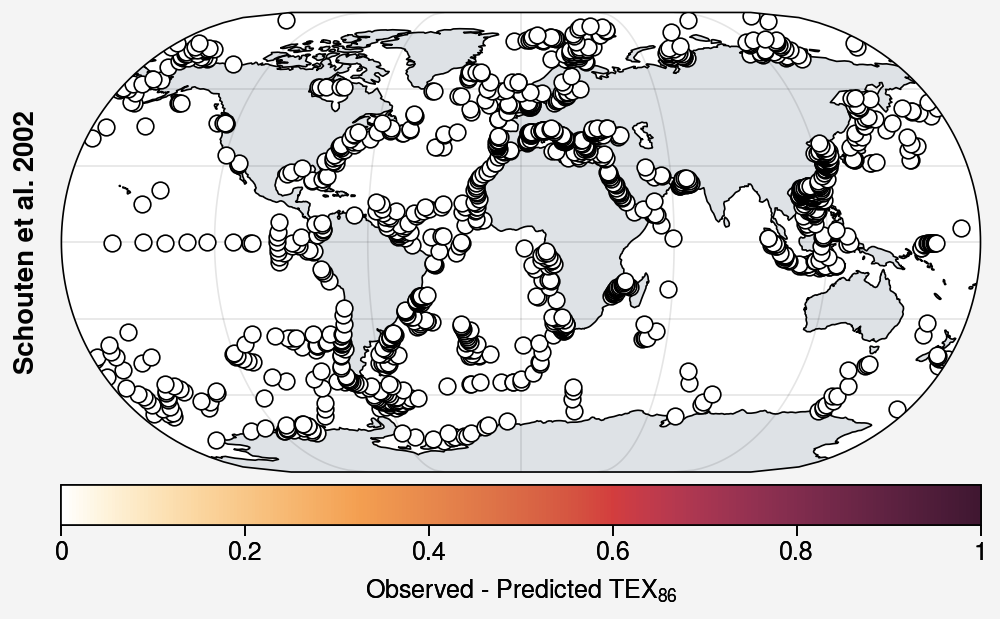

In [44]:
def plot_residual_map(method_='schouten02'):
    fig, axs = plot.subplots(proj='eck3',width=5)

    ax = axs[0]

    ax.format(land=True,landcolor='gray3',landzorder=0,
            coast=True,coastzorder=1)

    plot_data = coretop_df

    ### linear: schouten02, schouten03, kim2008, OBrien17
    ### non-linear: liu2009, kim2010_tex86H
    if method_ == 'bayspar_sst':
        plot_TEXres = plot_data['TEXres_BAYSPAR-sst']
    elif method_ == 'blank':
        plot_TEXres = np.full(len(plot_data),0.)
    else:
        plot_TEXres = plot_data['tex_median'] - predictTEXfromSST(plot_data['sst'],method_name=method_)
    m = ax.scatter(
        plot_data['lon'],plot_data['lat'],
        c=plot_TEXres if method_ != 'blank' else 'w',
        cmap='coldhot',
        levels=np.arange(-0.3,0.31,0.05),
        mec='k',
        zorder=2
    )

    ax.colorbar(m,loc='b',title=r'Observed - Predicted TEX$_{86}$')
    label_dict = {
        'blank':'Schouten et al. 2002',
        'schouten02':'Schouten et al. 2002',
        'kim2008':'Kim et al. 2008',
        'kim2010_tex86H': r'Kim et al. 2010 ($TEX^{H}_{86}$)',
        'bayspar_sst':'BAYSPAR (SST)'
    }
    ax.format(rowlabels=[label_dict.get(method_)])

    fpath = f'{local_github_path}/figures/viz_for_presentations/IMOG2025'
    fname = f'map01_{method_}_coretop_reasea_base'
    fig.savefig(
        os.path.join(fpath,fname+'.png'),
        box_inches='tight',embed_fonts=True,dpi=600,
        transparent=True
    )

    return fig, axs

plot_residual_map(method_='blank')

/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py:27: ProplotWarning: Got conflicting or duplicate keyword args: {'figwidth': 13.33, 'width': 12}. Using the first one.
  return new_figure_manager_given_figure(num, FigureClass(*args, **kwargs))
/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


<a list of 1 Line2D objects>

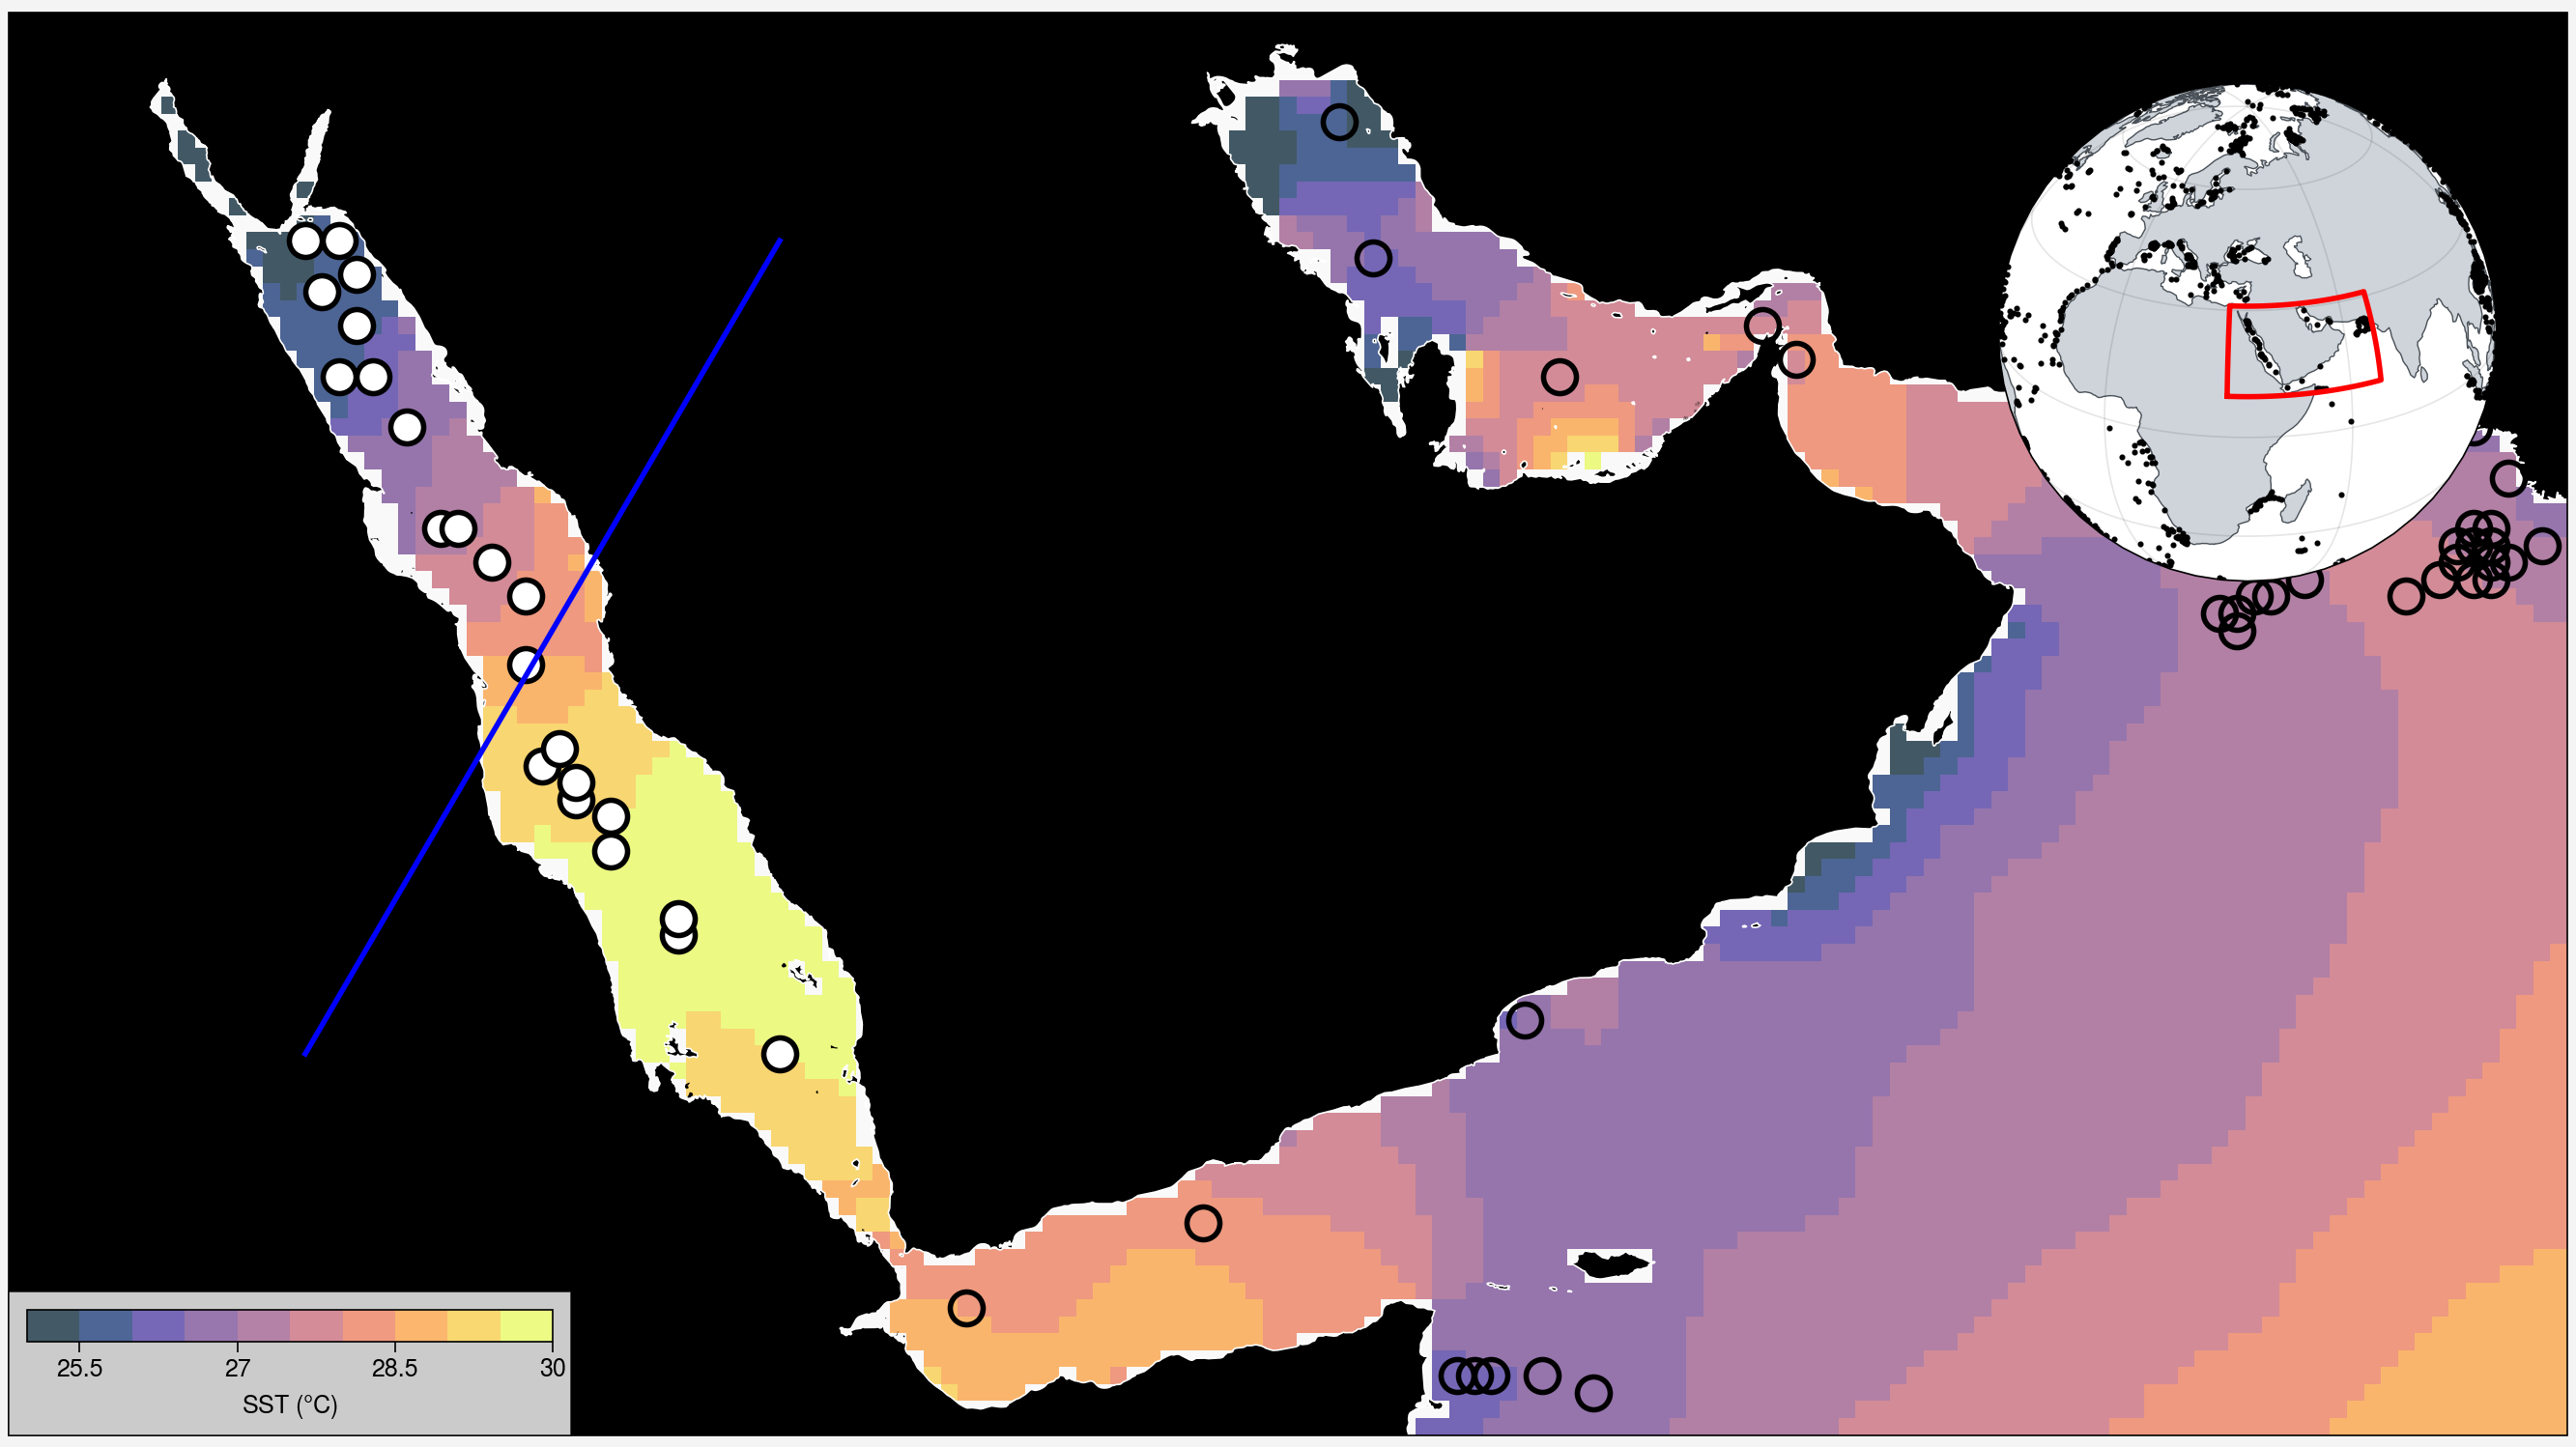

In [ ]:
fig, axs = plot.subplots(proj='cyl',width=12,figsize=(13.33,7.49))
plot.rc.reso = 'hi'
lon_min, lon_max = 30.25, 68
lat_min, lat_max = 10, 31
gmt_bathy_da = pygmt.datasets.load_earth_relief(resolution="30s", region=[lon_min,lon_max,lat_min,lat_max], registration=None, data_source='igpp', use_srtm=False)

ax = axs[0,0]
ax.format(
    latlabels=False,
    lonlabels=False,
    lonlim=(lon_min,lon_max),
    latlim=(lat_min,lat_max),
    coast=True,coastzorder=2,coastcolor='w',
    land=True,landzorder=1,landcolor='k',
    alpha=0.5,
    grid=False
)

plot_data = woa23_temp.isel(depth=0)
plot_lat = woa23_temp.lat
plot_lon = woa23_temp.lon

m = ax.pcolormesh(plot_lon,plot_lat,plot_data,cmap='thermal',levels=np.arange(25,30.5,0.5),alpha=0.75,zorder=0)
# ax.contour(plot_lon,plot_lat,plot_data,linecolor='black',linewidth=0.25,levels=np.arange(-5000,5100,200))
ax.colorbar(m,loc='ll',shrink=20,title=r'SST ($\degree$C)')

#####
# plot_x = coretop_df['lon']
# plot_y = coretop_df['lat']
# ax.scatter(plot_x,plot_y,c='w',mec='k',m='o',s=150,zorder=3)

grouped = coretop_df.groupby('region_ID')
for name, group in grouped:
    plot_x = group['lon']
    plot_y = group['lat']
    ax.scatter(plot_x,plot_y,
            # c='pink9' if name==31 else 'w',
            facecolor='w' if name==31 else 'none',
            mec='k',mew=2,
            m='o',s=150,zorder=3)


##########################
# Create an inset axis overlapping on the top right corner of axs[0]
plot.rc.reso = 'lo'
ax_inset = axs[0].inset_axes([0.7, 0.6, 0.35, 0.35],
                             proj='ortho',proj_kw={'lon_0':35,'lat_0':25})
ax_inset.format(land=True, 
                landcolor='gray4',landzorder=0,
                grid=True,
                coast=True, coastcolor='gray7',coastlinewidth=0.5,coastzorder=1,
                )


# Your modified code section:
# Replace this part:
# rect = Rectangle((lon_min,lat_min), lon_max - lon_min, lat_max - lat_min, edgecolor='red9',
#                  facecolor='none',transform=ccrs.PlateCarree())
# ax_inset.add_patch(rect)

# With this:
boundary_lons, boundary_lats = create_latlon_boundary(lon_min, lon_max, lat_min, lat_max, n_points=50)

# Method 1: Using plot (recommended - simple and effective)
ax_inset.plot(boundary_lons, boundary_lats, 'red', linewidth=2, 
              transform=ccrs.PlateCarree(), zorder=10)
ax_inset.scatter(coretop_df['lon'],coretop_df['lat'],m='.',c='k',s=10,zorder=2)

ax.plot(section_lons, section_lats, 'blue', linewidth=2, 
        transform=ccrs.PlateCarree(), zorder=11)


# fpath = f'{local_github_path}/figures/viz_for_presentations/IMOG2025'
# fname = 'thermocline_depth_reasea'
# fig.savefig(
#     os.path.join(fpath,fname+'.png'),
#     box_inches='tight',embed_fonts=True,dpi=600
# )

/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: print_figure() got unexpected keyword argument "box_inches" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: print_figure() got unexpected keyword argument "embed_fonts" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)


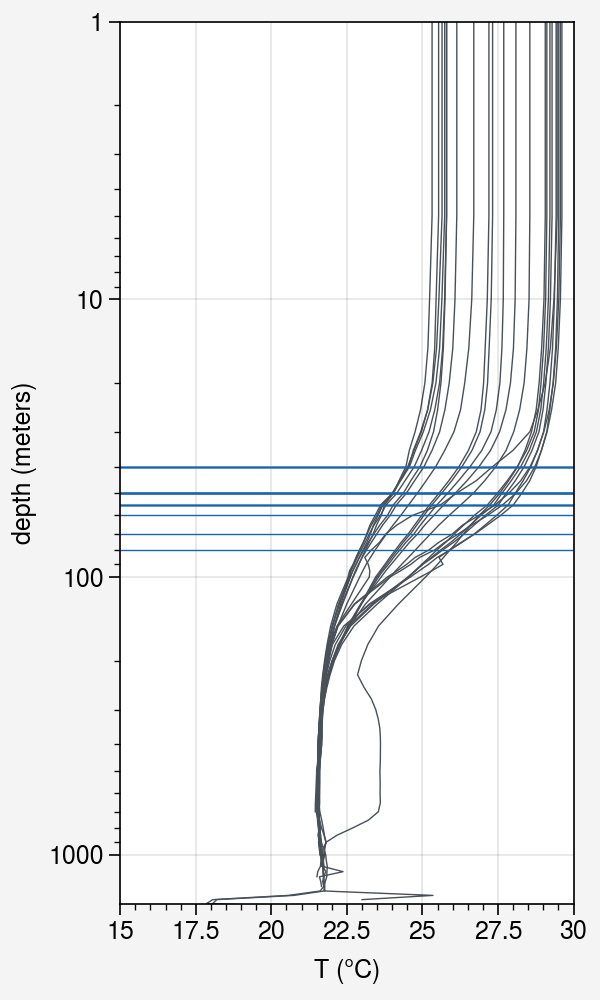

In [ ]:
fig, axs = plot.subplots(figsize=(3,5))

redsea_coretop_df = coretop_df[coretop_df['region_ID']==31].copy().reset_index(drop=True)

plot_x = coretop_df['lon']
plot_y = coretop_df['lat']

ax.scatter(plot_x,plot_y,c='w',mec='k',m='o',s=150,zorder=3)
redsea_lat_min, redsea_lat_max = redsea_coretop_df['lat'].min()-0.2, redsea_coretop_df['lat'].max()+0.2
redsea_lon_min, redsea_lon_max = redsea_coretop_df['lon'].min()-0.2, redsea_coretop_df['lon'].max()+0.2

plot_T_redsea = T_da['t_an'].sel(lon=slice(redsea_lon_min,redsea_lon_max),lat=slice(redsea_lat_min,redsea_lat_max)).squeeze(['time'])
plot_T_redsea_latlon_stacked = plot_T_redsea.stack(z=('lat','lon'))
random_idx = np.random.choice(len(plot_T_redsea_latlon_stacked.z), size=200, replace=False)
# for ii in range(len(random_idx)):
#     axs[0].plot(plot_T_redsea_latlon_stacked.isel(z=random_idx[ii]).values,plot_T_redsea.depth,c='gray5',lw=1,zorder=0)
    
    # ### plot thermocline depth for these random profiles
    # dTdz_random = np.diff(plot_T_redsea_latlon_stacked.isel(z=random_idx[ii]).values)/np.diff(plot_T_redsea.depth)
    # if np.all(np.isnan(dTdz_random)):
    #     continue
    # else:
    #     thermocline_depth_random = plot_T_redsea.depth[np.nanargmin(dTdz_random)]
    #     axs[0].axhline(thermocline_depth_random,c='blue5',lw=0.5,ls='--') 

for i in range(len(redsea_coretop_df)):
    match_lat = redsea_coretop_df.loc[i,'lat']
    match_lon = redsea_coretop_df.loc[i,'lon']
    Tprofile_ = T_da['t_an'].squeeze('time').sel(lat=match_lat,lon=match_lon,method='nearest').values
    depth_ = T_da.depth
    axs[0].plot(Tprofile_,depth_,c='gray7',lw=0.5,zorder=0)
    
    ### thermocline depth
    dTdz = np.diff(Tprofile_)/np.diff(depth_)
    thermocline_depth = depth_[np.nanargmin(dTdz)]
    axs[0].axhline(thermocline_depth,c='blue9',lw=0.5)
    
axs[0].format(
    ylim=(1500,1),
    xlim=(15,30),
    yscale='log',
    xlabel=f'T ($\degree$C)'
)

fpath = f'{local_github_path}/figures/viz_for_presentations/IMOG2025'
fname = 'T_profiles_coretop_reasea'
axs.format(facecolor='white')
fig.savefig(
    os.path.join(fpath,fname+'.png'),
    box_inches='tight',embed_fonts=True,dpi=600,
)

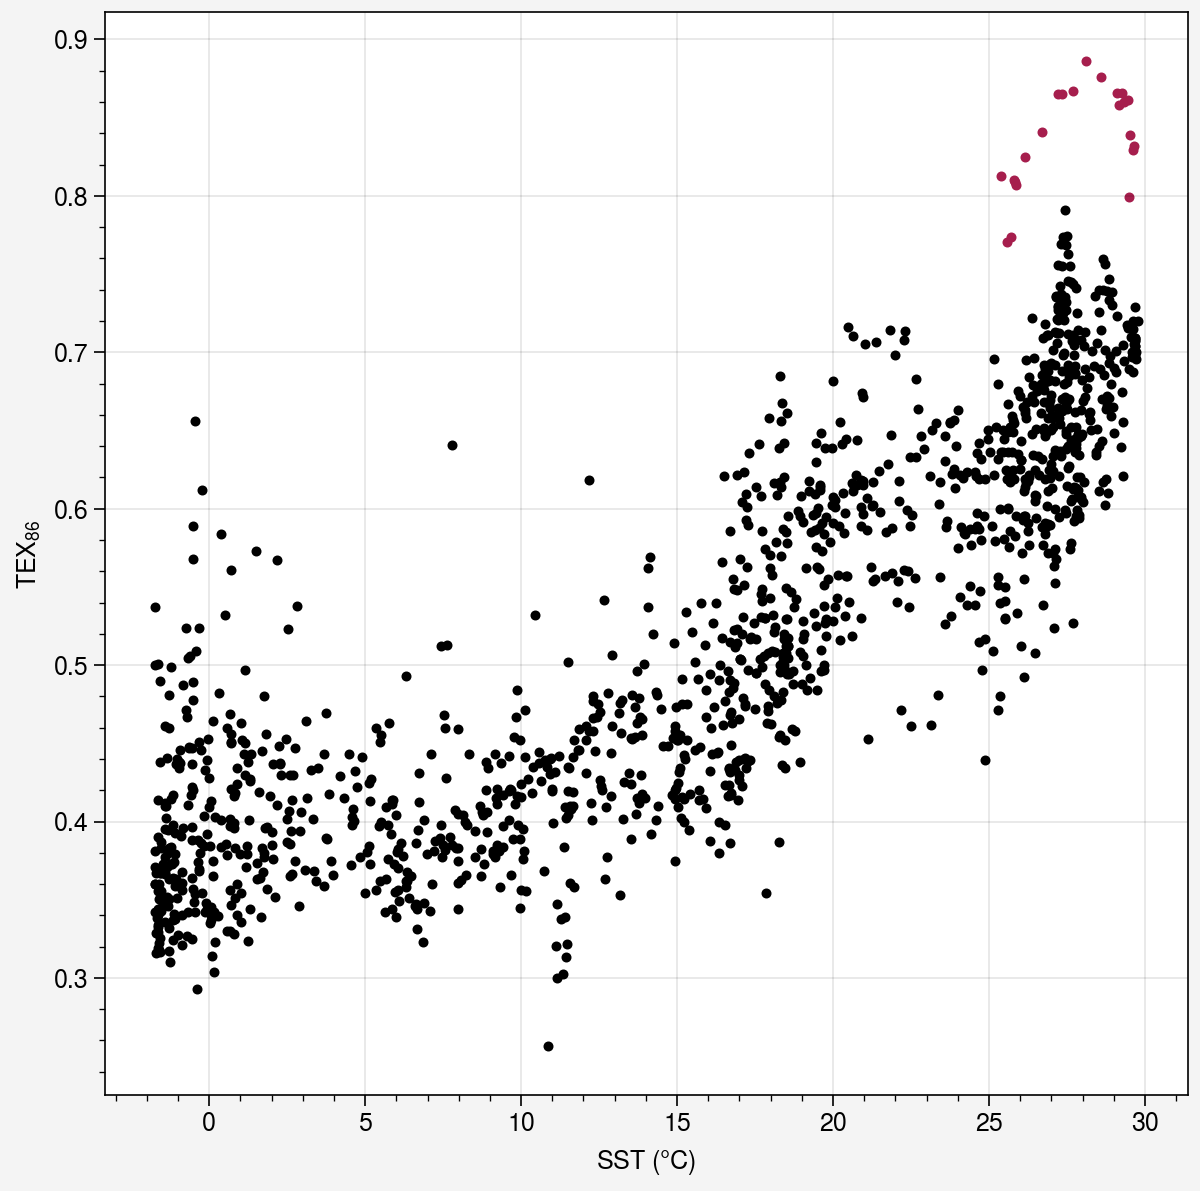

In [ ]:
fig, axs = plot.subplots(width=6)

lon_min, lon_max = 30.25, 68
lat_min, lat_max = 10, 31

grouped = coretop_df.groupby('region_ID')
ax = axs[0]

for name, group in grouped:
    plot_x = group['sst']
    plot_y = group['tex_median']
    ax.scatter(
        plot_x,plot_y,
        m = '.',
        c = 'pink9' if name==31 else 'k'
    )
    
ax.format(
    xlabel=r'SST ($\degree$C)',
    ylabel=r'TEX$_{86}$',
)
ax.set_facecolor('white') 
fpath = f'{local_github_path}/figures/viz_for_presentations/IMOG2025'
fname = 'SST-TEX_inset.png'
fig.savefig(os.path.join(fpath,fname), 
            transparent=True, 
            bbofacecolor='w' if name==31 else 'none',
            mec='k',mew=2,x_inches='tight')

/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py:27: ProplotWarning: Got conflicting or duplicate keyword args: {'figwidth': 13.33, 'width': 12}. Using the first one.
  return new_figure_manager_given_figure(num, FigureClass(*args, **kwargs))
/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/xarray/core/computation.py:761: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, u

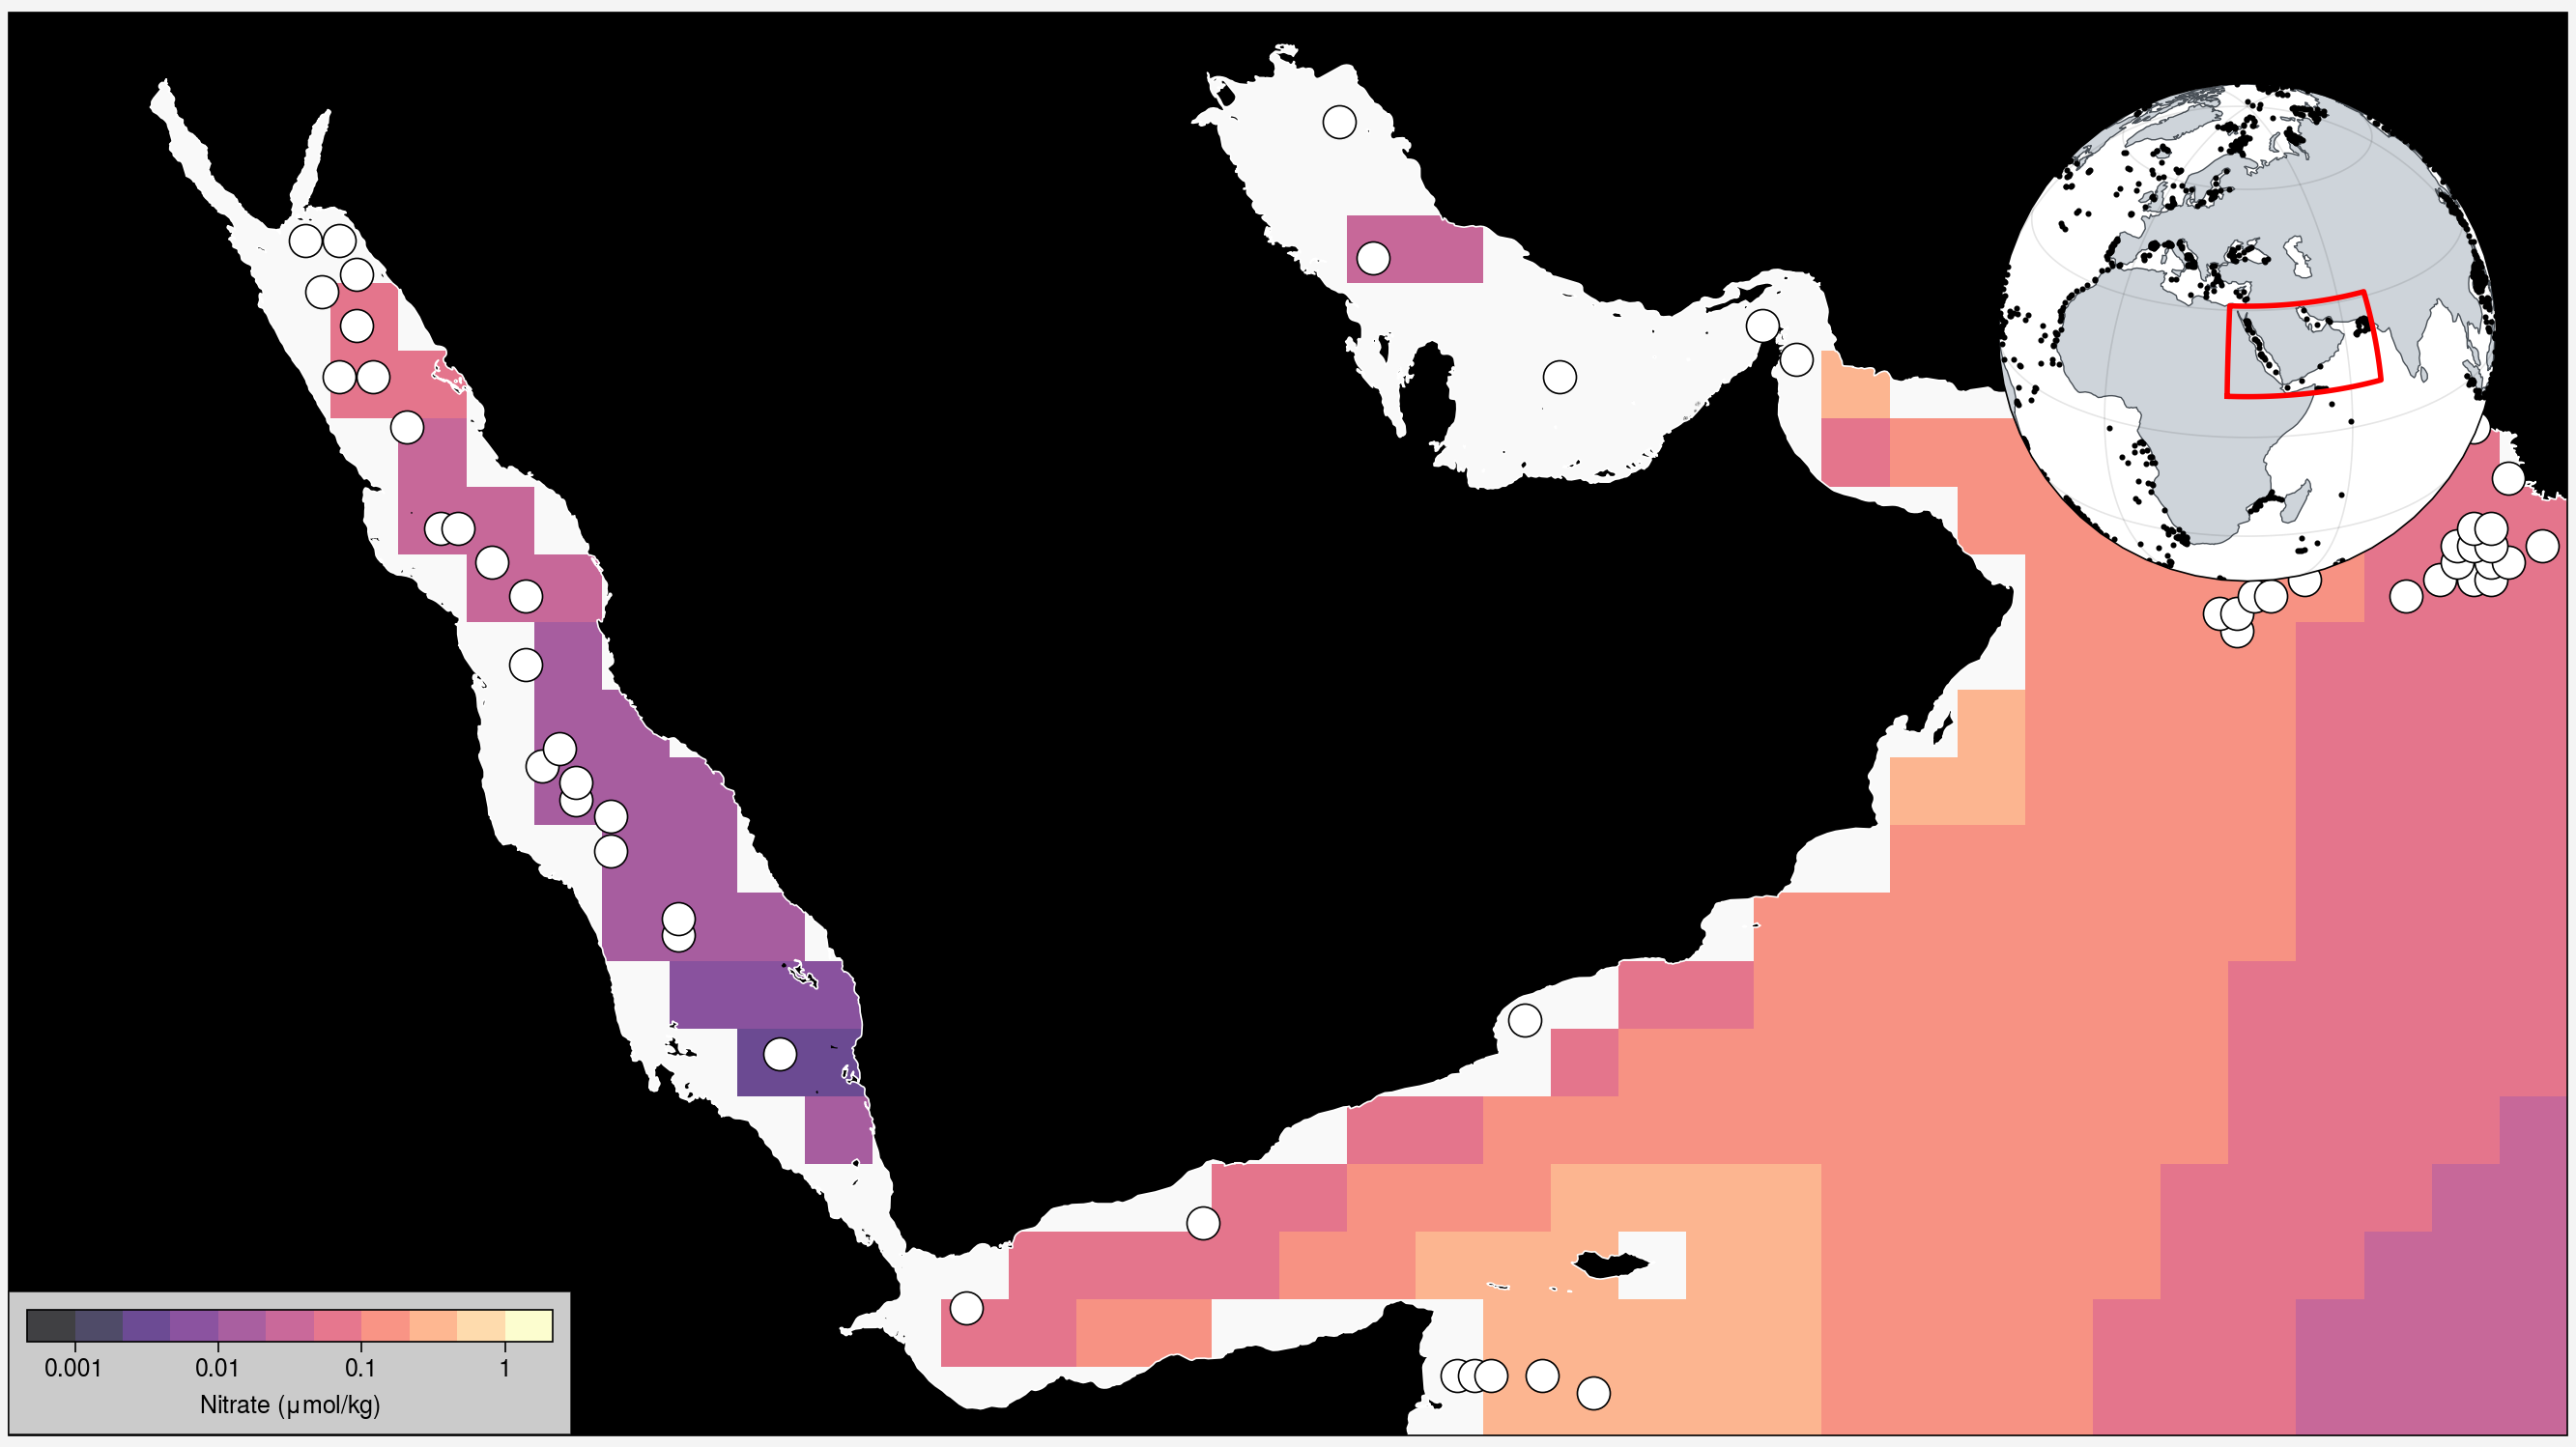

In [ ]:
fig, axs = plot.subplots(proj='cyl',width=12,figsize=(13.33,7.49))
plot.rc.reso = 'hi'
lon_min, lon_max = 30.25, 68
lat_min, lat_max = 10, 31
gmt_bathy_da = pygmt.datasets.load_earth_relief(resolution="30s", region=[lon_min,lon_max,lat_min,lat_max], registration=None, data_source='igpp', use_srtm=False)

ax = axs[0,0]
ax.format(
    latlabels=False,
    lonlabels=False,
    lonlim=(lon_min,lon_max),
    latlim=(lat_min,lat_max),
    coast=True,coastzorder=2,coastcolor='w',
    land=True,landzorder=1,landcolor='k',
    alpha=0.5,
    grid=False
)

plot_data = np.log10(woa23_no3.isel(depth=0))
plot_lat = woa23_no3.lat
plot_lon = woa23_no3.lon

m = ax.pcolormesh(plot_lon,plot_lat,plot_data,cmap='magma',
                  alpha=0.75,zorder=0)
# ax.contour(plot_lon,plot_lat,plot_data,linecolor='black',linewidth=0.25,levels=np.arange(-5000,5100,200))
ax.colorbar(m,loc='ll',shrink=20,title=r'Nitrate ($\mu$mol/kg)',
            ticklabels=['0.001','0.01','0.1','1','10'])

#####
# plot_x = coretop_df['lon']
# plot_y = coretop_df['lat']
# ax.scatter(plot_x,plot_y,c='w',mec='k',m='o',s=150,zorder=3)

grouped = coretop_df.groupby('region_ID')
for name, group in grouped:
    plot_x = group['lon']
    plot_y = group['lat']
    ax.scatter(plot_x,plot_y,
            #    c='pink9' if name==31 else 'w',
            c='w',
            mec='k',
            m='o',s=150,zorder=3)


##########################
# Create an inset axis overlapping on the top right corner of axs[0]
plot.rc.reso = 'lo'
ax_inset = axs[0].inset_axes([0.7, 0.6, 0.35, 0.35],
                             proj='ortho',proj_kw={'lon_0':35,'lat_0':25})
ax_inset.format(land=True, 
                landcolor='gray4',landzorder=0,
                grid=True,
                coast=True, coastcolor='gray7',coastlinewidth=0.5,coastzorder=1,
                )


# Your modified code section:
# Replace this part:
# rect = Rectangle((lon_min,lat_min), lon_max - lon_min, lat_max - lat_min, edgecolor='red9',
#                  facecolor='none',transform=ccrs.PlateCarree())
# ax_inset.add_patch(rect)

# With this:
boundary_lons, boundary_lats = create_latlon_boundary(lon_min, lon_max, lat_min, lat_max, n_points=50)

# Method 1: Using plot (recommended - simple and effective)
ax_inset.plot(boundary_lons, boundary_lats, 'red', linewidth=2, 
              transform=ccrs.PlateCarree(), zorder=10)
ax_inset.scatter(coretop_df['lon'],coretop_df['lat'],m='.',c='k',s=10,zorder=2)




fpath = f'{local_github_path}/figures/viz_for_presentations/IMOG2025/'
fname = 'map02_no3_coretop_reasea'
fig.savefig(
    os.path.join(fpath,fname+'.png'),
    box_inches='tight',embed_fonts=True,dpi=600
)

# Arabian Sea showcase

In [ ]:
### ocean properties dataset
fpath = fr'{local_github_path}/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'
ocean_properties_ds = xr.open_dataset(os.path.join(fpath,fname),decode_times=False)
ocean_properties_ds


<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [ ]:
t_sf2tc_da = ocean_properties_ds.t_sf2tc_avg
thermocline_depth_da = ocean_properties_ds.tc_depth
thermocline_nitrate_da = ocean_properties_ds.no3_sf2tc_avg

/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py:27: ProplotWarning: Got conflicting or duplicate keyword args: {'figwidth': 13.33, 'width': 12}. Using the first one.
  return new_figure_manager_given_figure(num, FigureClass(*args, **kwargs))
/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/proplot/

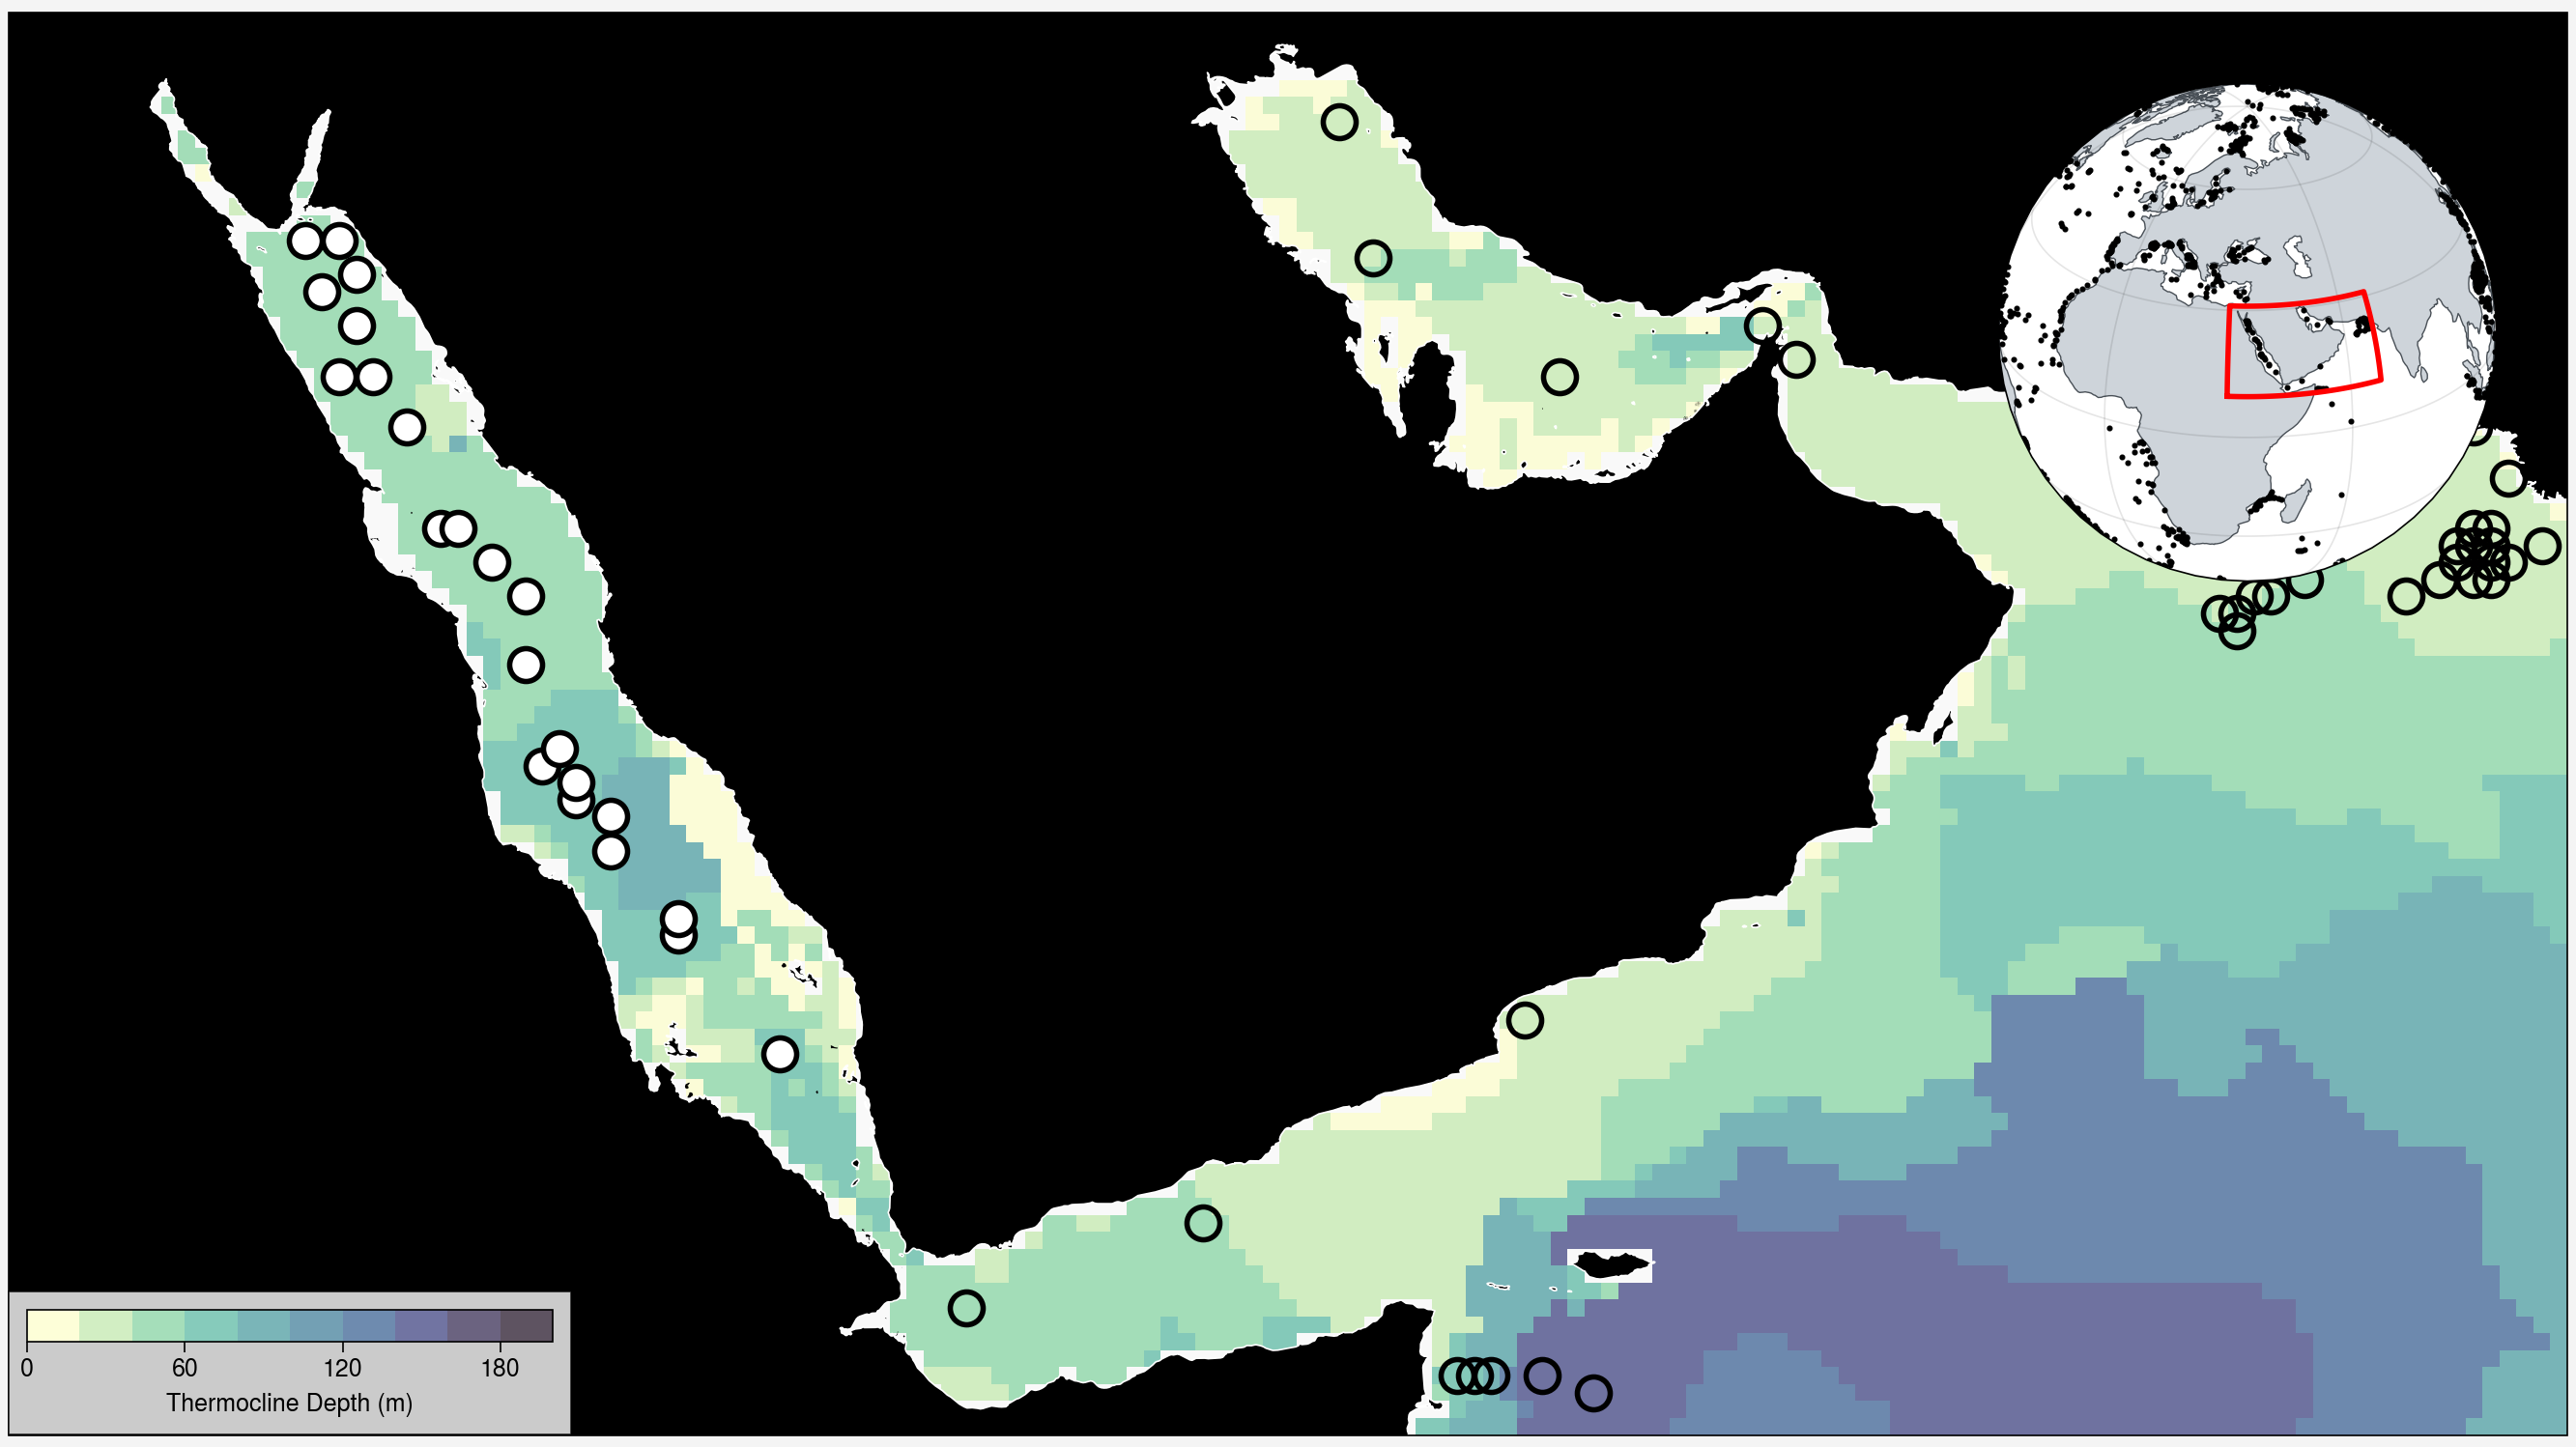

In [ ]:
fig, axs = plot.subplots(proj='cyl',width=12,figsize=(13.33,7.49))
plot.rc.reso = 'hi'
lon_min, lon_max = 30.25, 68
lat_min, lat_max = 10, 31
gmt_bathy_da = pygmt.datasets.load_earth_relief(resolution="30s", region=[lon_min,lon_max,lat_min,lat_max], registration=None, data_source='igpp', use_srtm=False)

ax = axs[0,0]
ax.format(
    latlabels=False,
    lonlabels=False,
    lonlim=(lon_min,lon_max),
    latlim=(lat_min,lat_max),
    coast=True,coastzorder=2,coastcolor='w',
    land=True,landzorder=1,landcolor='k',
    alpha=0.5,
    grid=False
)

plot_data = thermocline_depth_da
plot_lat = thermocline_depth_da.lat
plot_lon = thermocline_depth_da.lon

m = ax.pcolormesh(plot_lon,plot_lat,plot_data,cmap='deep',
                  alpha=0.75,zorder=0,levels=np.arange(0,201,20))
# ax.contour(plot_lon,plot_lat,plot_data,linecolor='black',linewidth=0.25,levels=np.arange(-5000,5100,200))
ax.colorbar(m,loc='ll',shrink=20,title=r'Thermocline Depth (m)')

#####
# plot_x = coretop_df['lon']
# plot_y = coretop_df['lat']
# ax.scatter(plot_x,plot_y,c='w',mec='k',m='o',s=150,zorder=3)

grouped = coretop_df.groupby('region_ID')
for name, group in grouped:
    plot_x = group['lon']
    plot_y = group['lat']
    ax.scatter(plot_x,plot_y,
            #    c='pink9' if name==31 else 'w',
            # c='w',
            # mec='k',
            facecolor='w' if name==31 else 'none',
            mec='k',mew=2,
            m='o',s=150,zorder=3)


##########################
# Create an inset axis overlapping on the top right corner of axs[0]
plot.rc.reso = 'lo'
ax_inset = axs[0].inset_axes([0.7, 0.6, 0.35, 0.35],
                             proj='ortho',proj_kw={'lon_0':35,'lat_0':25})
ax_inset.format(land=True, 
                landcolor='gray4',landzorder=0,
                grid=True,
                coast=True, coastcolor='gray7',coastlinewidth=0.5,coastzorder=1,
                )


# Your modified code section:
# Replace this part:
# rect = Rectangle((lon_min,lat_min), lon_max - lon_min, lat_max - lat_min, edgecolor='red9',
#                  facecolor='none',transform=ccrs.PlateCarree())
# ax_inset.add_patch(rect)

# With this:
boundary_lons, boundary_lats = create_latlon_boundary(lon_min, lon_max, lat_min, lat_max, n_points=50)

# Method 1: Using plot (recommended - simple and effective)
ax_inset.plot(boundary_lons, boundary_lats, 'red', linewidth=2, 
              transform=ccrs.PlateCarree(), zorder=10)
ax_inset.scatter(coretop_df['lon'],coretop_df['lat'],m='.',c='k',s=10,zorder=2)




fpath = f'{local_github_path}/figures/viz_for_presentations/IMOG2025/'
fname = 'map02_thermocline_depth_coretop_reasea'
fig.savefig(
    os.path.join(fpath,fname+'.png'),
    box_inches='tight',embed_fonts=True,dpi=600
)

/home/ronnie-rattan/miniforge3/envs/nutrient-effect-on-tex/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


TypeError: float() argument must be a string or a real number, not 'method'

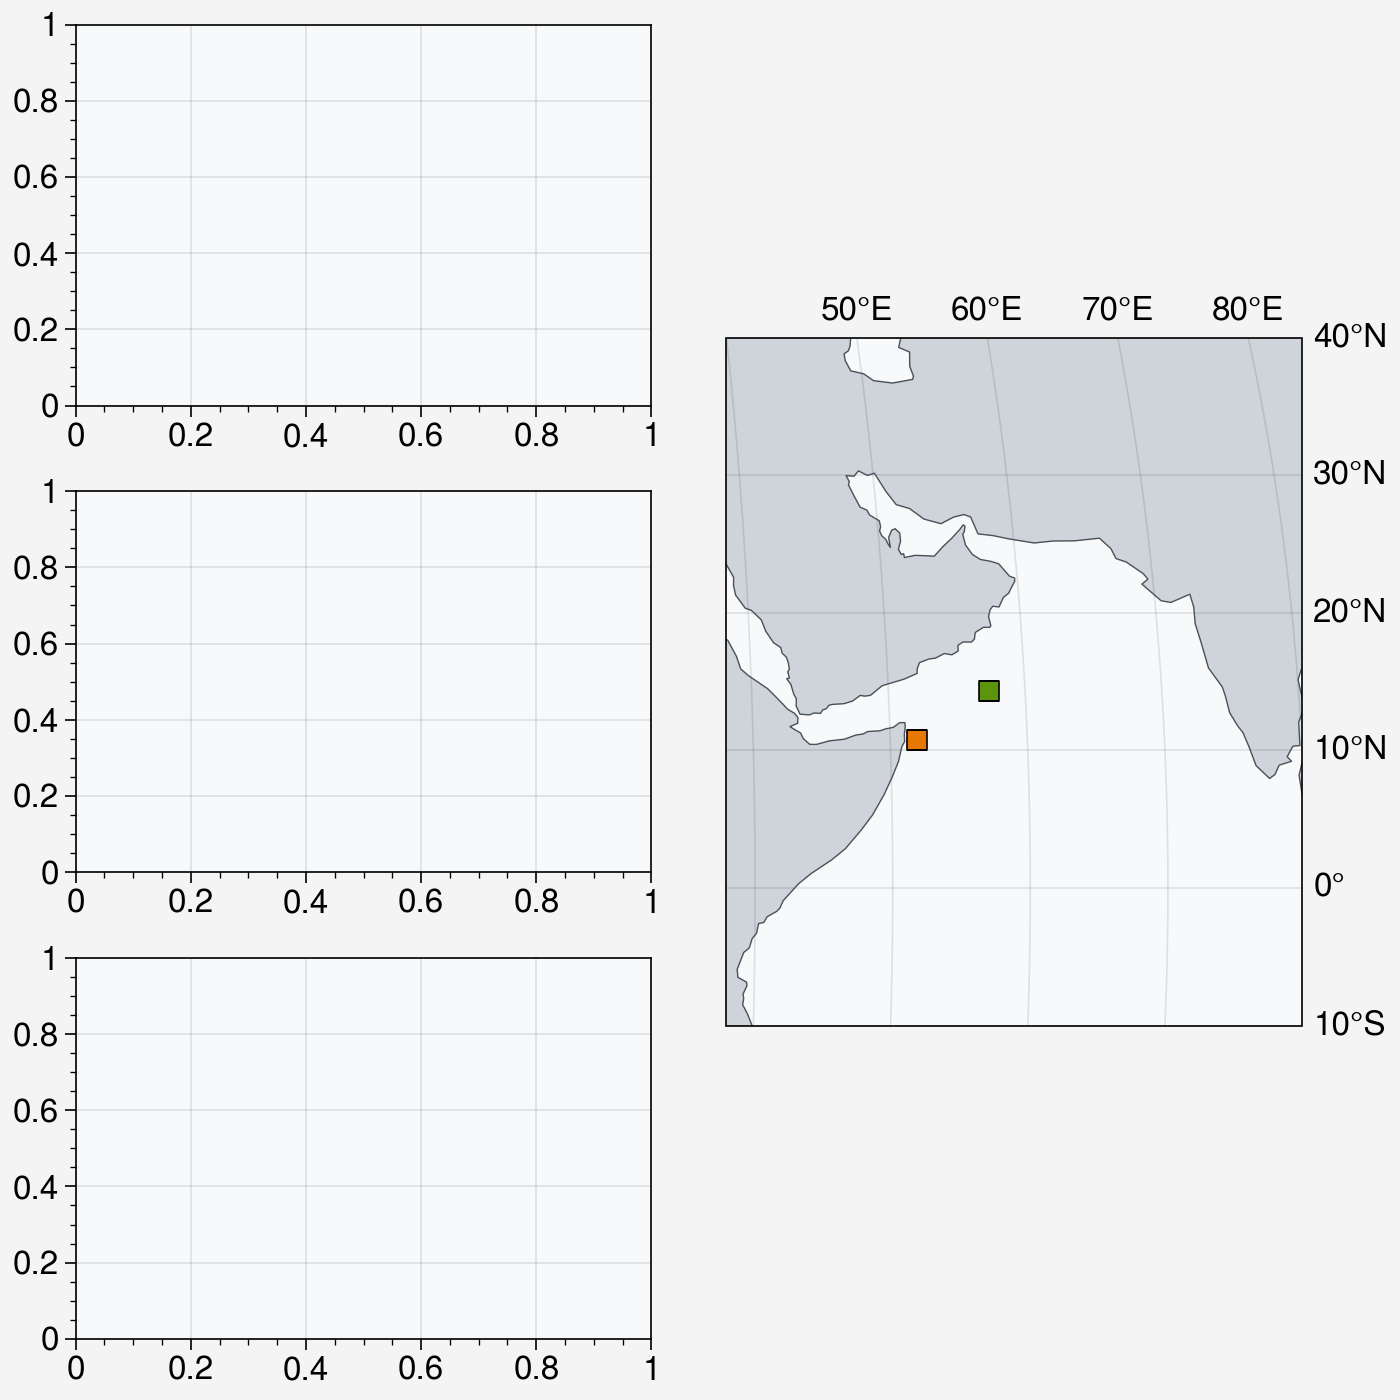

In [ ]:
array = [
    [1,1,4,4],
    [2,2,4,4],
    [3,3,4,4],
]
fig, axs = plot.subplots(
    array,
    figsize=(7,7),
    share=0,
    wspace=3,
    proj=(None,None,None,'eck3')
    )

axs.format(facecolor='gray0',fontsize=12)
########## site locations
ax = axs[3]
ax.format(land=True,landcolor='gray4',landzorder=0,
          coast=True,coastcolor='gray7',coastlinewidth=0.5,
          latlim=(-10,40),lonlim=(40,80),
          latlabels='r',lonlabels='t',
          labelsize=12,latlines=10,lonlines=10,)


### lat lon for NIOP-C2_905_PC = 10.767N,51.95E
### lat lon for SO42-74KL = 14.321N, 57.347E
ax.scatter(51.95,10.767,c='yellow9',
           mec='k',marker='s',s=50,
           label='NIOP-C2_905_PC',
           zorder=2)

ax.scatter(57.347,14.321,c='lime9',
           mec='k',marker='s',s=50,
           label='SO42-74KL',
           zorder=2)
### plot sst and thermoT of modern sst for two core locations
NIOP905_today_sst = T_da.isel(depth=0).sel(lat=10.767,lon=51.95,method='nearest').values
axs[1].scatter(-0.5,NIOP905_today_sst, c='yellow9', mec='k', mew=1, marker='o',s=80, clip_on=False)
NIOP905_today_thermoT = t_sf2tc_da.sel(lat=10.767,lon=51.95,method='nearest').values
axs[1].scatter(-0.5,NIOP905_today_thermoT, facecolor='none', mec='yellow9', mew=1, marker='o',s=80, clip_on=False)

SO42_today_sst = T_da.isel(depth=0).sel(lat=14.321,lon=57.347,method='nearest').values
axs[1].scatter(-0.5,SO42_today_sst, c='lime9', mec='k', mew=1, marker='o',s=80, clip_on=False)
SO42_today_thermoT = t_sf2tc_da.sel(lat=14.321,lon=57.347,method='nearest').values
axs[1].scatter(-0.5,SO42_today_thermoT, facecolor='none', mec='lime9',marker='o',s=80, clip_on=False)

### plot modern d15N for arabian sea regions

plot_data = coretop_gridded_d15N_ds.sel(lat=slice(10,20),
                                        lon=slice(50,60)
                                        ).to_dataframe().dropna(subset=['d15N_mean']).reset_index()

m=thermocline_nitrate_da.sel(lat=slice(-10,30),lon=slice(25,90)).plot(ax=ax,
                                                                    zorder=0,
                                                                    levels=[1e-3,1e-2,1e-1,1,lowno3_threshold,10],
                                                                    cmap='matter',
                                                                    add_colorbar=False,
                                                                    alpha=0.65,
                                                                    rasterized=True)
ax.set_title('')
### plot the lowno3_threshold μM contour line
m2=thermocline_nitrate_da.sel(lat=slice(-10,30),lon=slice(25,90)
                                       ).plot.contour(ax=ax,levels=[0,lowno3_threshold],
                                                        zorder=1,
                                                        linewidths=1,
                                                        linestyles='dashed',
                                                        colors='w',robust=True)

axins1 = inset_axes(
    ax,
    width="80%",
    height="10%",
    loc="lower center",
    bbox_to_anchor=(0,-0.2,1,1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

axins1.patch.set_alpha(0)
cbar = fig.colorbar(m,
             cax=axins1,
             orientation="horizontal",
             extend='both'
             )
cbar.set_label('Thermocline-integrated nitrate ($\mu$mol/L)', size=10)
cbar.ax.tick_params(labelsize=10)
cbar.add_lines(m2)
cbar.lines[0].set_linestyle('dashed')
axins1.xaxis.set_ticklabels(['0.001','0.01','0.1','1',f'{lowno3_threshold}','10'])

###### time series plot
ax = axs[0]
ax.format(
    ylabel='$\delta^{18}$O$_{SMOW}$',
)
plot_data = ngrip_df.dropna(how='all',subset=['d18O NGRIP1']).reset_index(drop=True)
plot_x = plot_data['Age']/1000
plot_y = plot_data['d18O NGRIP1']
ax.plot(plot_x,plot_y,c='gray7',lw=0.5,label='NGRIP')

plot_data = ngrip_df.dropna(how='all',subset=['d18O NGRIP2']).reset_index(drop=True)
plot_x = plot_data['Age']/1000
plot_y = plot_data['d18O NGRIP2']
ax.plot(plot_x,plot_y,c='gray7',lw=0.5,label='')


ax = axs[1]
ax.format(
    ylabel='Reconstructed T ($\degree$C)',
    yticks=[25,30,35],
)
plot_data = NIOP905_SST_df
plot_x = plot_data['Age_kaBP']
plot_y = plot_data['sst']
ax.plot(plot_x,plot_y,c='yellow9',lw=1)

plot_data = NIOP905_tex_df
plot_x = plot_data['Age']*1000
plot_y2 = plot_data['subT']
ax.plot(plot_x,plot_y2,c='yellow9',ls='--',lw=1)

plot_data = SO42_75KL_SST_df 
plot_x = plot_data['Age_kaBP']
plot_y = plot_data['sst']
ax.plot(plot_x,plot_y,c='lime9',lw=1)

plot_data = SO42_75KL_tex_df
plot_x = plot_data['Age']*1000
plot_y2 = plot_data['subT']
ax.plot(plot_x,plot_y2,c='lime9',ls='--',lw=1)

#### plotting d15N data


ax = axs[2]
ax.format(
    ylabel='$\delta^{15}$N (‰ vs. air)',
    ylim=(4,10.5)
)
    
#### add an arrow with annotation showing reduced denitrification during YD and HS1
ax.annotate('',
            xy=(16,10),xytext=(16,8),
            arrowprops=dict(arrowstyle='<|-',lw=1),
            ha='center',va='center',fontsize=8)
ax.text(16.3,10,'weakened\nsurface ocean\ndenitrification',
        ha='left',va='top',fontsize=9)

sel_sites = ['NIOP 905','SO42-74KL']
sel_colors = ['yellow9','lime9']
plot_data = downcore_d15N_df[downcore_d15N_df['core_name'].isin(sel_sites)].dropna(subset=['Age','d15N'])
grouped = plot_data.groupby('core_name')
for name, group in grouped:
    group = group.sort_values(by='Age').reset_index(drop=True)
    plot_x = group['Age']
    plot_y = group['d15N']
    ax.plot(plot_x,plot_y,
            c=sel_colors[sel_sites.index(name)],
            lw=1,ls='-.',label='site-specific $\delta^{15}$N$_{sed}$')

#### add shaded area highlighting Younger Dryas (YD; 12.9-11.7 ka) and Heinrich stadial 1 (HS1; 16.9-14.5 ka) for all plots
for ax in axs[:3]:
    ax.axvspan(11.7,12.9,color='blue9',alpha=0.1)
    ax.axvspan(14.7,17.5,color='blue9',alpha=0.1)
### add text labels for YD and HS1 at the top of subplot A
ax = axs[0]
ax.text(0.62,0.98,'YD',transform=ax.transAxes,
        ha='center',va='top',color='blue9',
        fontsize=10,fontweight='bold')
ax.text(0.82,0.98,'HS1',transform=ax.transAxes,
        ha='center',va='top',color='blue9',
        fontsize=10,fontweight='bold')



############################################################

h, l = axs[1].get_legend_handles_labels()
h2, l2 = axs[2].get_legend_handles_labels()
h3,l3 = axs[-1].get_legend_handles_labels()


axs[1].legend(h[1],loc='ur',c='k',
              frameon=False,
              ncols=1,
              bbox_to_anchor=(0,0,1,1),
              labels=['TEX$_{86}$ Thermo-T\n(linear-this study)'],
              fontsize=8,
              )
axs[1].legend(h[0],loc='ll',c='k',
              frameon=False,
              ncols=1,
              bbox_to_anchor=(0.1,0,1,1),
              labels=["U$^{K'}_{37}$ BAYSPLINE-SST"],
              fontsize=8,
              )


axs[2].legend([h2[i] for i in [1]],
              loc='ll',ncols=1,
              c='k',
              frameon=False,
              labels=['Site-specific $\delta^{15}$N$_{sed}$']
              )

axs[-1].legend(h3,loc='upper right',ncol=1,
               bbox_to_anchor=(0,0,1,1),
               labels=['NIOP-C2_905_PC','SO42-74KL'],)


## set the color for the first two marker elements as black

axs.format( abc=True,abcloc='ul',abcstyle='a',rc_kw={'abc.size':20})

axs[:,0].format(
    xlim=(-1,20),
    xlabel='Age (thousand years ago; ka)',
)

axs[:2,0].format(
    xlabel='',
    xticklabels=[],
)
### set ylims for each plot
axs[0].format(ylim=(-45.1,-32.1),yticks=[-45,-40,-35])
axs[1].set_ylim(22,39)
plt.show()

fpath = fr'{local_github_path}/figures/'
fname = 'paleo_showcase_ArabianSea.pdf'
fig.savefig(os.path.join(fpath,fname),bbox_inches='tight',embed_fonts=True,dpi=660)